# Exploratory Data Analysis - Predicting Tornadoes





## 1. Setup
### 1.1 Imports

We import the following packages, libraries, and modules

In [1]:

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import itertools
import sys
import pathlib

# access files in project directory no matter where this is ran
import notebook_file_utilities.auto_add_project_root as proroot 
project_root = proroot.auto_add_project_root()

# metadata 
import data.metadata.cleaned_feature_info as metadata

import src.cleaning.conditional_nan_imputer as condition




### 1.2 Load in Data

The following cell loads in the data from `data/event_station_indicator`.

In [2]:
path_to_event_station_indicator = pathlib.Path('data/event_station_indicator')
event_station_indicator=os.listdir(project_root/path_to_event_station_indicator)
csv_files = [project_root/path_to_event_station_indicator/pathlib.Path(file) for file in event_station_indicator if file.endswith('.csv')]
dataframes = [pd.read_csv(file) for file in csv_files]
data = pd.concat(dataframes,axis=0,ignore_index=True)


/var/folders/_y/61ngw3jd5739nsvht6fg3wfr0000gn/T/ipykernel_31980/2772227521.py:4: DtypeWarning: Columns (19,21) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframes = [pd.read_csv(file) for file in csv_files]
/var/folders/_y/61ngw3jd5739nsvht6fg3wfr0000gn/T/ipykernel_31980/2772227521.py:4: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframes = [pd.read_csv(file) for file in csv_files]
/var/folders/_y/61ngw3jd5739nsvht6fg3wfr0000gn/T/ipykernel_31980/2772227521.py:4: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframes = [pd.read_csv(file) for file in csv_files]
/var/folders/_y/61ngw3jd5739nsvht6fg3wfr0000gn/T/ipykernel_31980/2772227521.py:4: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframes = [pd.read_csv(file) for file in csv_files]
/var/folders/_y/61ngw3jd5739nsvht6fg3w

**Assumptions:**

1. In [src/cleaning/merged_tornado_indicator](../src/cleaning/merged_tornado_indicator.py) there are two important parameters: `time_window` and `val_radius` in the `create_tornado_indicator` function. 

    * `time_window`- time in hours 
    * `val_radius` - distance in kilometers

    Tornadoes are counted as occurring in a sample if the sample's station is within `val_radius`= 75 km away from the tornado's starting location and the station observes them within `time_window`=3 hours of the tornado's beginning time. The variables `val_radius` and `time_window` are parameters that can be modified if desired. 

2. In the station data from NOAA, we drop many columns that the raw data contains (see [src/cleaning/interim_station_data.py](../src/cleaning/interim_station_data.py) for implementation). For convenience  below is a list of the columns dropped and the reasons why.

```python
# Features to DROP before EDA - Based on station column names
features_to_drop_before_eda = [
    # ========================================
    # IDENTIFIERS & METADATA (not predictive)
    # ========================================
    'NAME',  # Station name
    'CALL_SIGN',  # Call sign identifier
    'CALL_SIGN.1',  # Duplicate call sign
    'SOURCE',  # Data source flag
    'SOURCE.1',  # Duplicate source
    'REPORT_TYPE',  # Report type code
    'REPORT_TYPE.1',  # Duplicate report type
    'QUALITY_CONTROL',  # QC process name
    'QUALITY_CONTROL.1',  # Duplicate QC
    'REM',  # Remarks section
    # ========================================
    # PRECIPITATION (not super predictive)
    # OTHER FEATURES LIKE SLP and DEW are more 
    # informative.
    # ========================================
    'AA1','AA2','AA3','AA4',
    # ========================================
    # POTENTIAL DATA LEAKAGE WEATHER OBSERVATIONS
    # ========================================
    'AT1', 'AT2', 'AT3', 'AT4', 'AT5', 'AT6','AT7', 'AT8',
    'AU1', 'AU2', 'AU3', 'AU4', 'AU5', 
    'AW1', 'AW2', 'AW3', 'AW4', 'AW5', 'AW6','AW7',
    # ========================================
    # MONTHLY/LONG-PERIOD SUMMARIES (not relevant for hourly forecasting)
    # ========================================
    'AB1',  # Liquid precipitation monthly total
    'AD1',  # Greatest liquid precip in 24 hours for month
    'AE1',  # Number of days with specific precip amounts for month
    'AH1', 'AH2', 'AH3', 'AH4', 'AH5', 'AH6',  # Max short duration precip for month (5-45 min)
    'AI1', 'AI2', 'AI3', 'AI4', 'AI5', 'AI6',  # Max short duration precip for month (60-180 min)
    'AK1',  # Greatest snow depth on ground for month
    'AM1',  # Greatest snow accumulation in 24 hours for month
    'AN1',  # Snow accumulation for day/month
    
    # ========================================
    # SNOW/ICE DATA (Oklahoma tornado season = spring/summer, no snow)
    # ========================================
    'AJ1',  # Snow depth
    'AL1',  # Snow accumulation
    
    # ========================================
    # PAST WEATHER (less predictive than current conditions)
    # ========================================
    'AX1', 'AX2', 'AX3', 'AX4', 'AX5', 'AX6',  # Past weather summary
    
    # ========================================
    # OBSCURE/RARELY REPORTED VARIABLES
    # ========================================
    'AG1',  # Estimated precipitation (from AFCCC)
    'ED1',  # Runway visual range (aviation-specific, rare)
    'EQD',  # Element quality data section
    'GA1', 'GA2', 'GA3', 'GA4', 'GA5', 'GA6',  # Sky cover summation (duplicative with CIG)
    'GD1', 'GD2', 'GD3', 'GD4',  # Sky cover layer (detailed cloud layers - keep if you want detail)
    'GE1',  # Sky condition/cloud genus
    'GF1',  # Sky cover layer base height
    'GJ1',  # Sunshine observation
    'GK1',  # Sunshine percent possible
    'GP1',  # Sky cover time period
    'GQ1',  # Sky condition method
    'GR1',  # Below station cloud layer
    'HL1',  # Hail size
    'IA1',  # Ground surface observation (soil temp, ground state)
    'KA1', 'KA2', 'KA3', 'KA4',  # Extreme air temperature (daily max/min - not hourly)
    'KB1', 'KB2', 'KB3',  # Average air temperature
    'KC1', 'KC2',  # Extreme temperature (manual observation)
    'KD1', 'KD2',  # Heating/cooling degree days
    'KE1',  # Extreme temperature (automated)
    'KG1', 'KG2',  # Average temperature (period)
    'MA1',  # Atmospheric pressure change
    'MD1',  # Atmospheric pressure tendency
    'MF1',  # Atmospheric pressure observation (geopotential height)
    'MG1',  # Atmospheric pressure observation (station pressure at observation level)
    'MH1',  # Atmospheric pressure observation (altimeter setting)
    'MK1',  # Atmospheric pressure observation (station pressure)
    'MV1',  # Present weather in vicinity
    'MW1', 'MW2', 'MW3', 'MW4', 'MW5',  # Manual atmospheric conditions (past weather)
    'OC1',  # Wind gust observation
    'OD1',  # Supplemental wind data
    'OE1', 'OE2', 'OE3',  # Wind summary observations
    'RH1', 'RH2', 'RH3',  # Relative humidity (can be derived from TMP and DEW)
    'SA1',  # Sea surface temperature (not relevant for Oklahoma)
    'UA1',  # Wave measurement (ocean, not relevant)
    'UG1',  # Wave direction (ocean, not relevant)
    'WA1',  # Platform ice accretion
]
```
3. In the station data from NOAA, the values of the features are packed into strings of comma separated values. In [src/processed_station_data.py](../src/processed_station_data.py) we unpack these values and convert their data types-- thereby creating new features (see ISD Documentation). Below is a dictionary describing this unpacking and the new feature names.

```python
# Dictionary mapping compound field names to their component column names
# Order matches ISD documentation exactly
isd_field_parsing_map = {
    # WIND-OBSERVATION (5 components)
    'WND': [
        'WND_direction_angle',
        'WND_direction_quality_code',
        'WND_type_code',
        'WND_speed_rate',
        'WND_speed_quality_code'
    ],
    
    # SKY-CONDITION-OBSERVATION ceiling (4 components)
    'CIG': [
        'CIG_ceiling_height',
        'CIG_ceiling_quality_code',
        'CIG_ceiling_determination_code',
        'CIG_cavok_code'
    ],
    
    # VISIBILITY-OBSERVATION (4 components)
    'VIS': [
        'VIS_distance',
        'VIS_distance_quality_code',
        'VIS_variability_code',
        'VIS_variability_quality_code'
    ],
    
    # AIR-TEMPERATURE-OBSERVATION air temperature (2 components)
    'TMP': [
        'TMP_air_temperature',
        'TMP_air_temperature_quality_code'
    ],
    
    # AIR-TEMPERATURE-OBSERVATION dew point (2 components)
    'DEW': [
        'DEW_dew_point',
        'DEW_dew_point_quality_code'
    ],
    
    # ATMOSPHERIC-PRESSURE-OBSERVATION sea level pressure (2 components)
    'SLP': [
        'SLP_sea_level_pressure',
        'SLP_sea_level_pressure_quality_code'
    ]
}

```




## 2. A Look at the Data

### 2.1 Sample CSV
The following code outputs a sample of 10 entries from `data` and saves the output to a [sample csv](<../results/eda_summaries/small_sample.csv>).

In [3]:


sample_of_data = data.sample(10)
display(sample_of_data)

# Save to csv
sample_of_data_path = pathlib.Path('results/eda_summaries/small_sample.csv')
sample_of_data.to_csv(project_root/sample_of_data_path)


,STATION,LATITUDE,LONGITUDE,ELEVATION,DATE,WND_direction_angle,WND_direction_quality_code,WND_type_code,WND_speed_rate,WND_speed_quality_code,...,VIS_variability_code,VIS_variability_quality_code,TMP_air_temperature,TMP_air_temperature_quality_code,DEW_dew_point,DEW_dew_point_quality_code,SLP_sea_level_pressure,SLP_sea_level_pressure_quality_code,TORNADO_OCCURRENCE,TORNADO_BEGIN_DATE_TIME
865840,72357003948,35.2500,-97.46667,360.3,2021-04-24 12:15:00,330,1,N,82,1,...,9,9,118,1,108,1,99999,9,False,NaN
1100647,72353013967,35.3889,-97.60060,391.7,2014-06-04 00:52:00,170,5,N,67,5,...,N,5,300,5,189,5,10088,5,False,NaN
664664,72357003948,35.2500,-97.46667,360.3,2016-04-17 17:15:00,110,5,N,57,5,...,N,5,150,5,150,5,99999,9,False,NaN
945151,72357099999,35.2330,-97.45000,345.0,2004-06-20 05:11:00,100,1,N,31,1,...,N,1,200,1,170,1,99999,9,False,NaN
691214,72354499999,35.5330,-97.65000,396.0,2000-06-23 17:00:00,999,9,9,9999,9,...,9,9,9999,9,9999,9,99999,9,False,NaN
850206,72357003948,35.2500,-97.46667,360.3,2020-05-10 04:30:00,140,5,N,41,5,...,N,5,157,5,81,5,99999,9,False,NaN
1235593,72353013967,35.3889,-97.60060,391.7,2001-07-24 08:52:00,160,5,N,31,5,...,N,1,261,5,217,5,10103,5,False,NaN
492790,72357003948,35.2500,-97.46667,360.3,2010-02-11 09:11:00,150,5,N,26,5,...,N,5,10,5,-40,5,99999,9,False,NaN
1309798,72353013967,35.3889,-97.60060,391.7,2017-08-31 21:52:00,40,5,N,46,5,...,N,5,283,5,144,5,10141,5,False,NaN
1038995,72354099999,35.4170,-97.38300,397.0,2004-10-09 11:00:00,20,1,N,31,1,...,N,1,160,1,160,1,10171,1,False,NaN



### 2.2 Shape of the Data: 


In [4]:
##  Data Overview
### data shape
row,col = data.shape

print(f"The data has {row} rows and {col} columns")

The data has 1370635 rows and 26 columns


### 2.3 Dtypes and Non-nan Counts:

The cell below outputs the Dtypes and Non-nan counts for the data. We also copy the output here.

```output 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1370635 entries, 0 to 1370634
Data columns (total 26 columns):
 #   Column                               Non-Null Count    Dtype         
---  ------                               --------------    -----         
 0   STATION                              1370635 non-null  int64         
 1   LATITUDE                             1370635 non-null  float64       
 2   LONGITUDE                            1370635 non-null  float64       
 3   ELEVATION                            1370635 non-null  float64       
 4   DATE                                 1370635 non-null  datetime64[ns]
 5   WND_direction_angle                  1370635 non-null  int64         
 6   WND_direction_quality_code           1370635 non-null  object        
 7   WND_type_code                        1370635 non-null  object        
 8   WND_speed_rate                       1370635 non-null  int64         
 9   WND_speed_quality_code               1370635 non-null  object        
 10  CIG_ceiling_height                   1370635 non-null  int64         
 11  CIG_ceiling_quality_code             1370635 non-null  int64         
 12  CIG_ceiling_determination_code       1370635 non-null  object        
 13  CIG_cavok_code                       1370635 non-null  object        
 14  VIS_distance                         1370635 non-null  int64         
 15  VIS_distance_quality_code            1370635 non-null  object        
 16  VIS_variability_code                 1370635 non-null  object        
 17  VIS_variability_quality_code         1370635 non-null  object        
 18  TMP_air_temperature                  1370635 non-null  int64         
 19  TMP_air_temperature_quality_code     1370635 non-null  object        
 20  DEW_dew_point                        1370635 non-null  int64         
 21  DEW_dew_point_quality_code           1370635 non-null  object        
 22  SLP_sea_level_pressure               1370635 non-null  int64         
 23  SLP_sea_level_pressure_quality_code  1370635 non-null  int64         
 24  TORNADO_OCCURRENCE                   1370635 non-null  bool          
 25  TORNADO_BEGIN_DATE_TIME              2271 non-null     datetime64[ns]
dtypes: bool(1), datetime64[ns](2), float64(3), int64(10), object(10)
memory usage: 262.7+ MB

```



In [5]:
# Insure that 'DATE' and 'TORNADO_BEGIN_DATE_TIME' are datetime types.
data['DATE']=pd.to_datetime(data['DATE'])
data['TORNADO_BEGIN_DATE_TIME']=pd.to_datetime(data['TORNADO_BEGIN_DATE_TIME'])
data.info(verbose = True)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1370635 entries, 0 to 1370634
Data columns (total 26 columns):
 #   Column                               Non-Null Count    Dtype         
---  ------                               --------------    -----         
 0   STATION                              1370635 non-null  int64         
 1   LATITUDE                             1370635 non-null  float64       
 2   LONGITUDE                            1370635 non-null  float64       
 3   ELEVATION                            1370635 non-null  float64       
 4   DATE                                 1370635 non-null  datetime64[ns]
 5   WND_direction_angle                  1370635 non-null  int64         
 6   WND_direction_quality_code           1370635 non-null  object        
 7   WND_type_code                        1370635 non-null  object        
 8   WND_speed_rate                       1370635 non-null  int64         
 9   WND_speed_quality_code               1370635 non-null  ob

### 2.4 Basic Statistics of Numerical Data:

The code below runs `data.describe()`. The output of the cell is also written to [results/eda_summaries/numerical_data_summary.csv](<../results/eda_summaries/numerical_data_summary.csv>).



In [6]:


# output of data.describe() does not display all columns, so we save
# result in "results/eda_summaries/numerical_data_summary.csv"
data_description=data.describe()
data_description_path =pathlib.Path("results/eda_summaries/numerical_data_summary.csv")
data_description.to_csv(project_root/data_description_path)
display(data_description)

,STATION,LATITUDE,LONGITUDE,ELEVATION,DATE,WND_direction_angle,WND_speed_rate,CIG_ceiling_height,CIG_ceiling_quality_code,VIS_distance,TMP_air_temperature,DEW_dew_point,SLP_sea_level_pressure,SLP_sea_level_pressure_quality_code,TORNADO_BEGIN_DATE_TIME
count,1.370635e+06,1.370635e+06,1.370635e+06,1.370635e+06,1370635,1.370635e+06,1.370635e+06,1.370635e+06,1.370635e+06,1.370635e+06,1.370635e+06,1.370635e+06,1.370635e+06,1.370635e+06,2271
mean,7.277508e+10,3.537449e+01,-9.752021e+01,3.806161e+02,2010-10-03 04:53:27.084584704,3.003746e+02,8.098321e+02,2.295962e+04,4.508287e+00,8.988368e+04,9.064984e+02,8.877034e+02,5.618098e+04,6.580434e+00,2011-04-08 20:11:05.574636288
min,7.235301e+10,3.523300e+01,-9.765000e+01,3.450000e+02,2000-01-01 00:00:00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,-2.440000e+02,-3.100000e+02,9.619000e+03,1.000000e+00,2000-10-22 15:14:00
25%,7.235401e+10,3.525000e+01,-9.760060e+01,3.603000e+02,2005-04-23 03:00:00,1.400000e+02,3.100000e+01,2.400000e+03,5.000000e+00,1.600000e+04,8.900000e+01,2.000000e+01,1.015600e+04,5.000000e+00,2007-03-29 15:05:00
50%,7.235440e+10,3.538890e+01,-9.746667e+01,3.917000e+02,2010-08-24 19:54:00,1.800000e+02,4.600000e+01,2.200000e+04,5.000000e+00,1.609300e+04,1.800000e+02,1.220000e+02,9.999900e+04,9.000000e+00,2011-11-07 22:47:00
75%,7.235700e+10,3.541700e+01,-9.745000e+01,3.935000e+02,2015-12-22 11:57:30,3.300000e+02,7.200000e+01,2.200000e+04,5.000000e+00,1.609300e+04,2.600000e+02,1.900000e+02,9.999900e+04,9.000000e+00,2015-05-23 17:30:00
max,9.999990e+10,3.554113e+01,-9.738300e+01,3.970000e+02,2021-12-31 23:56:00,9.990000e+02,9.999000e+03,9.999900e+04,9.000000e+00,9.999990e+05,9.999000e+03,9.999000e+03,9.999900e+04,9.000000e+00,2021-10-26 23:36:00
std,3.382089e+09,1.080019e-01,9.899477e-02,1.798491e+01,NaN,3.030131e+02,2.646457e+03,2.679792e+04,2.201026e+00,2.621199e+05,2.608570e+03,2.694011e+03,4.490615e+04,2.752561e+00,NaN


#### 2.4.1 Data Description Observations: 

Observe that some values in e.g `TMP_air_temperature` are absurdly high. The reason for this is because the NOAA station data has scaled some values; these are summarized and noted in [data/metadata](../data/metadata/cleaned_feature_info). For convineince we provide the dictionary summarizing these things here

```python
# Importable dictionaries based on datatype consisting of information about the numerical isd features 
# use in data after the NaN value cleanup in EDA. 

isd_int_columns_station = {
    'STATION': {
        'units': 'identifier code',
        'description': 'Unique numeric identifier for the station (WMO, WBAN, or USAF code).',
        'notes': 'Acts as primary key when merging with station metadata or other ISD files.'
    }
}

isd_float_columns_station = {
    # --- Station metadata ---
    'LATITUDE': {
        'units': 'decimal degrees (°N)',
        'range': '-90 to +90',
        'description': 'Latitude of station location.'
    },
    'LONGITUDE': {
        'units': 'decimal degrees (°E)',
        'range': '-180 to +180',
        'description': 'Longitude of station location.'
    },
    'ELEVATION': {
        'units': 'meters above mean sea level (m)',
        'range': '-400 to ~6000 typical',
        'description': 'Elevation of the station above mean sea level.'
    }
}

isd_float_meteor_columns = {
    # --- Sky condition ---
    'CIG_ceiling_height': {
        'units': 'meters',
        'scale': 1,
        'range': '0–22000 (22000 = unlimited ceiling)',
        'description': 'Height of lowest cloud layer reported as ceiling.',
        'missing_value': 99999,
        'notes': 'Value of 99999 may indicate unlimited ceiling if CIG_cavok_code is N or Y.'
    },
    
    # --- Temperature and Dew Point ---
    'DEW_dew_point': {
        'units': 'degrees Celsius',
        'scale': 10,
        'range': '-93.2 to +61.8°C typical',
        'description': 'Dew point temperature (scaled by 10).',
        'missing_value': 9999,
        'notes': 'Divide by 10 to get actual temperature in °C. Value 9999 indicates missing.'
    },
    'TMP_air_temperature': {
        'units': 'degrees Celsius',
        'scale': 10,
        'range': '-93.2 to +61.8°C typical',
        'description': 'Ambient (dry-bulb) temperature (scaled by 10).',
        'missing_value': 9999,
        'notes': 'Divide by 10 to get actual temperature in °C. Value 9999 indicates missing.'
    },
    
    # --- Pressure ---
    'SLP_sea_level_pressure': {
        'units': 'hectopascals (hPa)',
        'scale': 10,
        'description': 'Pressure reduced to mean sea level (scaled by 10).',
        'missing_value': 99999,
        'notes': 'Divide by 10 to get actual pressure in hPa. Value 99999 indicates missing.'
    },
    
    # --- Visibility ---
    'VIS_distance': {
        'units': 'meters',
        'scale': 1,
        'description': 'Horizontal visibility distance (in meters).',
        'missing_value': 999999,
        'notes': 'Value of 999999 may indicate unlimited visibility if CIG_cavok_code is Y or N.'
    },
    
    # --- Wind ---
    'WND_direction_angle': {
        'units': 'degrees true (0–360)',
        'scale': 1,
        'description': 'Direction from which wind is blowing.',
        'missing_value': 999,
        'notes': 'Value 999 may indicate variable wind (if WND_type_code is V) or calm wind (if WND_type_code is C).'
    },
    'WND_speed_rate': {
        'units': 'meters per second (m/s)',
        'scale': 10,
        'description': 'Wind speed (scaled by 10).',
        'missing_value': 9999,
        'notes': 'Divide by 10 to get actual speed in m/s. Value 9999 indicates missing. Value 0 with WND_type_code=9 indicates calm.'
    },
}

isd_station_datetime_columns = {
    'DATE': {
        'units': 'UTC datetime',
        'description': 'Timestamp of station observation (UTC).',
        'format': 'ISO 8601 datetime string or pandas datetime object'
    }
}

derived_tornado_datetime_columns = {
    'TORNADO_BEGIN_DATE_TIME': {
        'units': 'UTC datetime',
        'description': 'Tornado event start time.',
        'format': 'ISO 8601 datetime string or pandas datetime object'
    }
}

isd_categorical_meteor_columns = {
    # --- Wind type ---
    'WND_type_code': {
        'units': 'categorical',
        'description': 'Wind observation type code.',
        'values': {
            'A': 'Abridged Beaufort',
            'B': 'Beaufort',
            'C': 'Calm',
            'H': 'Estimated (5-minute average)',
            'N': 'Normal',
            'R': 'Estimated (1-minute rapid)',
            'Q': 'Squall',
            'T': 'Estimated (180-second)',
            'V': 'Variable',
            '9': 'Missing'
        },
        'notes': 'C = calm wind, V = variable direction, 9 = missing. If type_code=9 and speed=0, infer calm wind.'
    },
    'WND_direction_quality_code': {
        'units': 'categorical',
        'description': 'Quality code for wind direction measurement.',
        'values': {
            '0': 'Passed gross limits check',
            '1': 'Passed all quality control checks',
            '2': 'Suspect',
            '3': 'Erroneous',
            '4': 'Passed gross limits check, data originate from NCEI',
            '5': 'Passed all quality control checks, data originate from non-NCEI source',
            '6': 'Suspect, data originate from non-NCEI source',
            '7': 'Erroneous, data originate from non-NCEI source',
            '9': 'Missing'
        },
        'notes': 'Codes 3, 6, 9 indicate poor quality or missing data.'
    },
    'WND_speed_quality_code': {
        'units': 'categorical',
        'description': 'Quality code for wind speed measurement.',
        'values': {
            '0': 'Passed gross limits check',
            '1': 'Passed all quality control checks',
            '2': 'Suspect',
            '3': 'Erroneous',
            '4': 'Passed gross limits check, data originate from NCEI',
            '5': 'Passed all quality control checks, data originate from non-NCEI source',
            '6': 'Suspect, data originate from non-NCEI source',
            '7': 'Erroneous, data originate from non-NCEI source',
            '9': 'Missing'
        },
        'notes': 'Codes 3, 6, 9 indicate poor quality or missing data.'
    },
    
    # --- Ceiling ---
    'CIG_ceiling_quality_code': {
        'units': 'categorical (numeric)',
        'description': 'Quality code for ceiling height measurement.',
        'values': {
            0: 'Passed gross limits check',
            1: 'Passed all quality control checks',
            2: 'Suspect',
            3: 'Erroneous',
            4: 'Passed gross limits check, data originate from NCEI',
            5: 'Passed all quality control checks, data originate from non-NCEI source',
            6: 'Suspect, data originate from non-NCEI source',
            7: 'Erroneous, data originate from non-NCEI source',
            9: 'Missing'
        },
        'notes': 'Codes 3, 6, 9 indicate poor quality or missing data. Stored as integer.'
    },
    'CIG_ceiling_determination_code': {
        'units': 'categorical',
        'description': 'Method used to determine ceiling.',
        'values': {
            'A': 'Aircraft',
            'B': 'Balloon',
            'C': 'Statistically derived',
            'D': 'Persistent cirriform ceiling (pre-1950)',
            'E': 'Estimated',
            'M': 'Measured',
            'P': 'Precipitation ceiling (pre-1950)',
            'R': 'Radar',
            'S': 'ASOS augmented',
            'U': 'Unknown',
            'V': 'Variable',
            'W': 'Obscured',
            '9': 'Missing'
        },
        'notes': 'W with ceiling=99999 indicates clear below 12,000 feet.'
    },
    'CIG_cavok_code': {
        'units': 'categorical',
        'description': 'CAVOK (Ceiling And Visibility OK) indicator.',
        'values': {
            'N': 'No',
            'Y': 'Yes',
            '9': 'Missing'
        },
        'notes': 'Y or N with ceiling=99999 indicates unlimited ceiling. Y with visibility=999999 indicates unlimited visibility.'
    },
    
    # --- Visibility ---
    'VIS_distance_quality_code': {
        'units': 'categorical',
        'description': 'Quality code for visibility measurement.',
        'values': {
            '0': 'Passed gross limits check',
            '1': 'Passed all quality control checks',
            '2': 'Suspect',
            '3': 'Erroneous',
            '4': 'Passed gross limits check, data originate from NCEI',
            '5': 'Passed all quality control checks, data originate from non-NCEI source',
            '6': 'Suspect, data originate from non-NCEI source',
            '7': 'Erroneous, data originate from non-NCEI source',
            '9': 'Missing'
        },
        'notes': 'Codes 3, 6, 9 indicate poor quality or missing data.'
    },
    'VIS_variability_code': {
        'units': 'categorical',
        'description': 'Visibility variability code.',
        'values': {
            'N': 'Not variable',
            'V': 'Variable',
            '9': 'Missing'
        }
    },
    'VIS_variability_quality_code': {
        'units': 'categorical',
        'description': 'Quality code for visibility variability.',
        'values': {
            '0': 'Passed gross limits check',
            '1': 'Passed all quality control checks',
            '2': 'Suspect',
            '3': 'Erroneous',
            '4': 'Passed gross limits check, data originate from NCEI',
            '5': 'Passed all quality control checks, data originate from non-NCEI source',
            '6': 'Suspect, data originate from non-NCEI source',
            '7': 'Erroneous, data originate from non-NCEI source',
            '9': 'Missing'
        },
        'notes': 'Codes 3, 6, 9 indicate poor quality or missing data.'
    },
    
    # --- Temperature ---
    'TMP_air_temperature_quality_code': {
        'units': 'categorical',
        'description': 'Quality code for air temperature measurement.',
        'values': {
            '0': 'Passed gross limits check',
            '1': 'Passed all quality control checks',
            '2': 'Suspect',
            '3': 'Erroneous',
            '4': 'Passed gross limits check, data originate from NCEI',
            '5': 'Passed all quality control checks, data originate from non-NCEI source',
            '6': 'Suspect, data originate from non-NCEI source',
            '7': 'Erroneous, data originate from non-NCEI source',
            '9': 'Missing'
        },
        'notes': 'Codes 3, 6, 9 indicate poor quality or missing data.'
    },
    'DEW_dew_point_quality_code': {
        'units': 'categorical',
        'description': 'Quality code for dew point measurement.',
        'values': {
            '0': 'Passed gross limits check',
            '1': 'Passed all quality control checks',
            '2': 'Suspect',
            '3': 'Erroneous',
            '4': 'Passed gross limits check, data originate from NCEI',
            '5': 'Passed all quality control checks, data originate from non-NCEI source',
            '6': 'Suspect, data originate from non-NCEI source',
            '7': 'Erroneous, data originate from non-NCEI source',
            '9': 'Missing'
        },
        'notes': 'Codes 3, 6, 9 indicate poor quality or missing data.'
    },
    
    # --- Pressure ---
    'SLP_sea_level_pressure_quality_code': {
        'units': 'categorical (numeric)',
        'description': 'Quality code for sea level pressure measurement.',
        'values': {
            0: 'Passed gross limits check',
            1: 'Passed all quality control checks',
            2: 'Suspect',
            3: 'Erroneous',
            4: 'Passed gross limits check, data originate from NCEI',
            5: 'Passed all quality control checks, data originate from non-NCEI source',
            6: 'Suspect, data originate from non-NCEI source',
            7: 'Erroneous, data originate from non-NCEI source',
            9: 'Missing'
        },
        'notes': 'Codes 3, 6, 9 indicate poor quality or missing data. Stored as integer.'
    },
}

derived_tornado_bool_columns = {
    'TORNADO_OCCURRENCE': {
        'units': 'boolean',
        'description': 'True if a tornado occurred within the valid radius and time window for the station record.',
        'notes': 'Created by spatial-temporal matching between station observations and tornado event records.'
    }
}
```

**Once we deal with NaN values** (some NaN values in ISD documentation are numbers) we apply these scales to our numerical columns.

### 2.5 Data Quality and Cleaning Checks

The code below prints the number of types in each column. This is important to do for type validation and to follow the ISD documentation conventions for NaN values. We copy the next cells output here:

``` output
STATION
<class 'int'>    1370635
Name: count, dtype: int64

LATITUDE
<class 'float'>    1370635
Name: count, dtype: int64

LONGITUDE
<class 'float'>    1370635
Name: count, dtype: int64

ELEVATION
<class 'float'>    1370635
Name: count, dtype: int64

DATE
<class 'pandas._libs.tslibs.timestamps.Timestamp'>    1370635
Name: count, dtype: int64

WND_direction_angle
<class 'int'>    1370635
Name: count, dtype: int64

WND_direction_quality_code
<class 'int'>    1255572
<class 'str'>     115063
Name: count, dtype: int64

WND_type_code
<class 'str'>    1370635
Name: count, dtype: int64

WND_speed_rate
<class 'int'>    1370635
Name: count, dtype: int64

WND_speed_quality_code
<class 'int'>    1123750
<class 'str'>     246885
Name: count, dtype: int64

CIG_ceiling_height
<class 'int'>    1370635
Name: count, dtype: int64

CIG_ceiling_quality_code
<class 'int'>    1370635
Name: count, dtype: int64

CIG_ceiling_determination_code
<class 'str'>    1370635
Name: count, dtype: int64

CIG_cavok_code
<class 'str'>    1370635
Name: count, dtype: int64

VIS_distance
<class 'int'>    1370635
Name: count, dtype: int64

VIS_distance_quality_code
<class 'int'>    1123750
<class 'str'>     246885
Name: count, dtype: int64

VIS_variability_code
<class 'str'>    1370635
Name: count, dtype: int64

VIS_variability_quality_code
<class 'int'>    1123750
<class 'str'>     246885
Name: count, dtype: int64

TMP_air_temperature
<class 'int'>    1370635
Name: count, dtype: int64

TMP_air_temperature_quality_code
<class 'str'>    774981
<class 'int'>    595654
Name: count, dtype: int64

DEW_dew_point
<class 'int'>    1370635
Name: count, dtype: int64

DEW_dew_point_quality_code
<class 'str'>    774981
<class 'int'>    595654
Name: count, dtype: int64

SLP_sea_level_pressure
<class 'int'>    1370635
Name: count, dtype: int64

SLP_sea_level_pressure_quality_code
<class 'int'>    1370635
Name: count, dtype: int64

TORNADO_OCCURRENCE
<class 'bool'>    1370635
Name: count, dtype: int64

TORNADO_BEGIN_DATE_TIME
<class 'pandas._libs.tslibs.nattype.NaTType'>         1368364
<class 'pandas._libs.tslibs.timestamps.Timestamp'>       2271
Name: count, dtype: int64

```



In [7]:
for col in data.columns:    
    coldata = data[col]
    print(f"{coldata.apply(lambda r: type(r)).value_counts()}\n")
    

STATION
<class 'int'>    1370635
Name: count, dtype: int64

LATITUDE
<class 'float'>    1370635
Name: count, dtype: int64

LONGITUDE
<class 'float'>    1370635
Name: count, dtype: int64

ELEVATION
<class 'float'>    1370635
Name: count, dtype: int64

DATE
<class 'pandas._libs.tslibs.timestamps.Timestamp'>    1370635
Name: count, dtype: int64

WND_direction_angle
<class 'int'>    1370635
Name: count, dtype: int64

WND_direction_quality_code
<class 'int'>    1255572
<class 'str'>     115063
Name: count, dtype: int64

WND_type_code
<class 'str'>    1370635
Name: count, dtype: int64

WND_speed_rate
<class 'int'>    1370635
Name: count, dtype: int64

WND_speed_quality_code
<class 'int'>    1123750
<class 'str'>     246885
Name: count, dtype: int64

CIG_ceiling_height
<class 'int'>    1370635
Name: count, dtype: int64

CIG_ceiling_quality_code
<class 'int'>    1370635
Name: count, dtype: int64

CIG_ceiling_determination_code
<class 'str'>    1370635
Name: count, dtype: int64

CIG_cavok_code


## 3 Handling NaN Values  

### 3.1 NaN Replacements According to ISD Documentation**

Some of the features coming from the station data have NaN values that indicate meaningful data. These exceptions are interpreted from the [ISD Documentation](<../data/stations/isd-format-document.pdf>). Moreover, these exceptions are encoded in the `isd_conditional_meanings` in [data/metadata/cleaned_feature_info](../data/metadata/cleaned_feature_info). Note that a a flag is created `WND_direction_angle_variable_wind_direction_flag`.


The code below checks for and implements these changes.


In [8]:
data = condition.handle_conditional_meanings(data)

  WND_direction_angle: Found 13147 'variable_wind_direction' cases (Variable wind direction)
  WND_direction_angle: Found 82619 'calm_wind' cases (Calm wind (wind speed near zero))
  WND_type_code: Found 21 'calm_inferred' cases (Calm wind inferred from zero speed)


### 3.2 ISD NaN and Poor Quality Codes

Now that we have imputed values for particular conditions above, there are a number of features from the station datasets that have alternate codes for NaN values and codes for poor quality data. The dictionary, `isd_missing_and_poor_quality_codes` in [data/metadata/cleaned_feature_info.py](data/metadata/cleaned_feature_info.py)

In [9]:
isd_missing_and_poor_quality_codes=metadata.isd_missing_and_poor_quality_codes 

# Apply ISD conventions
for col, vals in isd_missing_and_poor_quality_codes.items():
    data[col].replace(to_replace=vals, value= np.nan,inplace = True)
    for val in vals:
    	assert((data[col][data[col]==val]).sum()==0) #make sure changes are implemented

/var/folders/_y/61ngw3jd5739nsvht6fg3wfr0000gn/T/ipykernel_31980/1550564372.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].replace(to_replace=vals, value= np.nan,inplace = True)



### 3.3 Count Missing Values

The following code counts how many NaN values in each column. We save the output of the code to [results/eda_summaries/nan_count.csv](<results/eda_summaries/nan_count.csv>). 

In [10]:
## Data Quality and Cleaning Checks

nan_count = data.isna().sum()
nan_count_path = pathlib.Path('results/eda_summaries/nan_count.csv')
nan_count.to_csv(project_root/nan_count_path)
display(nan_count)

STATION                                                   0
LATITUDE                                                  0
LONGITUDE                                                 0
ELEVATION                                                 0
DATE                                                      0
WND_direction_angle                                  118444
WND_direction_quality_code                            10003
WND_type_code                                        104519
WND_speed_rate                                       104967
WND_speed_quality_code                                10653
CIG_ceiling_height                                   131675
CIG_ceiling_quality_code                             132114
CIG_ceiling_determination_code                       988567
CIG_cavok_code                                        99353
VIS_distance                                         104965
VIS_distance_quality_code                             10335
VIS_variability_code                    

### 3.4 Frequency of Missing Values

Since our dataset is quite large, the actual counts of missing values is not immediately enlightening, so we also include the frequencies of these missing values. The code below does this and saves the results to [results/eda_summaries/nan_freq.csv](<results/eda_summaries/nan_freq.csv>).

In [11]:
nan_freq = (data.isna().sum())/len(data)
nan_freq_path = pathlib.Path('results/eda_summaries/nan_freq.csv')
nan_freq.to_csv(project_root/nan_freq_path)
display(nan_freq)

STATION                                             0.000000
LATITUDE                                            0.000000
LONGITUDE                                           0.000000
ELEVATION                                           0.000000
DATE                                                0.000000
WND_direction_angle                                 0.086415
WND_direction_quality_code                          0.007298
WND_type_code                                       0.076256
WND_speed_rate                                      0.076583
WND_speed_quality_code                              0.007772
CIG_ceiling_height                                  0.096069
CIG_ceiling_quality_code                            0.096389
CIG_ceiling_determination_code                      0.721247
CIG_cavok_code                                      0.072487
VIS_distance                                        0.076581
VIS_distance_quality_code                           0.007540
VIS_variability_code    

### 3.5 Features with more than 50% NaN*

The following code finds features from `data` have more than 50% NaN values and prints out their NaN frequency. Following a few important observations, the output is recorded for convenience.

It is important to note that: 

* The NaN values for `TORNADO_BEGIN_DATE_TIME` have meaning. Namely, that no tornado occurred. Since this column is a form of data leakage, we will drop it before test-train splitting the data.

* The NaN values in `CIG_ceiling_determination_code` are indicating that the method used to record the ceiling is missing. We do not think that this is too serious of an issue for the values in `CIG_ceiling_height`. **Furthermore, this column will be dropped anyway as this is metadata**.


* Since `SLP_sea_level_pressure` is likely an important factor in tornado likelihood and has an NaN frequency of `0.5122618348429743`, just above the .5 threshold, we will keep this column.

```output
The following features have more than 50% NaN values:

Feature `CIG_ceiling_determination_code` has `0.7212474509989896` NaN frequency

Feature `SLP_sea_level_pressure` has `0.5122618348429743` NaN frequency

Feature `SLP_sea_level_pressure_quality_code` has `0.5130257143586732` NaN frequency

Feature `TORNADO_BEGIN_DATE_TIME` has `0.9983431037438851` NaN frequency
```



In [12]:

print(f'The following features have more than 50% NaN values:\n')
for idx in nan_freq.index:
    
    if nan_freq[idx]>=.5:
        print(f'Feature `{idx}` has `{nan_freq[idx]}` NaN frequency\n')

The following features have more than 50% NaN values:

Feature `CIG_ceiling_determination_code` has `0.7212474509989896` NaN frequency

Feature `SLP_sea_level_pressure` has `0.5122618348429743` NaN frequency

Feature `SLP_sea_level_pressure_quality_code` has `0.5130257143586732` NaN frequency

Feature `TORNADO_BEGIN_DATE_TIME` has `0.9983431037438851` NaN frequency



### 3.6 Handling NaN Values 

#### 3.6.1 Drop Rows with NaN Values in Quality Codes

As a rule, we will drop any row that has a NaN in the following quality code columns since this represents bad or missing data.
* `WND_direction_quality_code`
* `WND_speed_quality_code`
* `CIG_ceiling_quality_code`
* `VIS_distance_quality_code`
* `VIS_variability_quality_code` 
* `TMP_air_temperature_quality_code` 
* `SLP_sea_level_pressure_quality_code`
* `CIG_cavok_code`



In [13]:
quality_code_feats = [
'WND_direction_quality_code',
'WND_speed_quality_code',
'CIG_ceiling_quality_code',
'VIS_distance_quality_code',
'VIS_variability_quality_code',
'TMP_air_temperature_quality_code',
'SLP_sea_level_pressure_quality_code',
'DEW_dew_point_quality_code',
'CIG_cavok_code'
]

data = data.dropna(subset=quality_code_feats)

for col in quality_code_feats:
    assert(data[col].isna().sum() ==0) # make sure there are no nan values in quality_code_feats

#### 3.6.2 New NaN Frequency

In [14]:
post_qual_drop_nan_freq = (data.isna().sum())/len(data)
post_qual_drop_nan_freq_path = pathlib.Path('results/eda_summaries/post_qual_drop_nan_freq.csv')
nan_freq.to_csv(project_root/post_qual_drop_nan_freq_path)
display(post_qual_drop_nan_freq)

STATION                                             0.000000
LATITUDE                                            0.000000
LONGITUDE                                           0.000000
ELEVATION                                           0.000000
DATE                                                0.000000
WND_direction_angle                                 0.019661
WND_direction_quality_code                          0.000000
WND_type_code                                       0.003328
WND_speed_rate                                      0.003483
WND_speed_quality_code                              0.000000
CIG_ceiling_height                                  0.000000
CIG_ceiling_quality_code                            0.000000
CIG_ceiling_determination_code                      0.662421
CIG_cavok_code                                      0.000000
VIS_distance                                        0.001048
VIS_distance_quality_code                           0.000000
VIS_variability_code    

### 3.6.3 Final NaN Row Drops

We will drop rows with NaN values in the following columns, as they are integral to our story and there are relatively few of them. Furthermore, we have already implemented conditional NaN imputing above.

* `WND_direction_angle`
* `WND_type_code`
* `WND_speed_rate`
* `VIS_variability_code`
* `TMP_air_temperature`
* `DEW_dew_point`

Note that with `WND_direction_angle` some care is needed since it has a flag feature associated with it: `WND_direction_angle_variable_wind_direction_flag`. 

In [15]:
print("before ",data['WND_direction_angle_variable_wind_direction_flag'].sum())
additional_nan_drops = [
    'WND_type_code',
    'WND_speed_rate',
    'VIS_variability_code',
    'TMP_air_temperature',
    'DEW_dew_point',
    'VIS_distance'
]
data = data.dropna(subset=additional_nan_drops)

false_variable_wind_flag = (data['WND_direction_angle_variable_wind_direction_flag'] == False)
(data.loc[false_variable_wind_flag]).dropna(subset = ['WND_direction_angle'], inplace = True)
print("after", data['WND_direction_angle_variable_wind_direction_flag'].sum())


before  10125
after 10065


/var/folders/_y/61ngw3jd5739nsvht6fg3wfr0000gn/T/ipykernel_31980/1910130732.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  (data.loc[false_variable_wind_flag]).dropna(subset = ['WND_direction_angle'], inplace = True)


## 4. Final Cleaning

### 4.1 Columns to Drop

We drop quality codes (except for CAVOK). We don't drop CAVOK since this is acts as a CIG and VIS flag. We also drop `CIG_ceiling_determination_code`. These are likely not too important in tornado detection-- just nan handling. We also drop `TORNADO_BEGIN_DATE_TIME` -- this was only used for merging station and event data. Furthermore, if we keep it, it is a form of data leakage post train-test split. 

In [16]:
features_to_drop = [
'WND_direction_quality_code',
'WND_speed_quality_code',
'CIG_ceiling_quality_code',
'VIS_distance_quality_code',
'VIS_variability_quality_code',
'TMP_air_temperature_quality_code',
'SLP_sea_level_pressure_quality_code',
'CIG_ceiling_determination_code',
'DEW_dew_point_quality_code',
'TORNADO_BEGIN_DATE_TIME'
]

data = data.drop(columns= features_to_drop,inplace = False)

### 4.2 Duplicate Detection

The code below checks for duplicates and, indeed, finds 20 of them. 

In [17]:
# Duplicate Check
data.duplicated().sum()


np.int64(77)

The cell below displays the first few rows of duplicated data. Note that as opposed to the cell above, which only counted duplicated value exactly once, the next cell will capture all duplicated rows and their copies. 

Upon examining the next cells output, we find that the duplicates found by `data.duplicated()` in the cell above, are indeed duplicates. 

In [18]:
data[data.duplicated(keep=False)]


,STATION,LATITUDE,LONGITUDE,ELEVATION,DATE,WND_direction_angle,WND_type_code,WND_speed_rate,CIG_ceiling_height,CIG_cavok_code,VIS_distance,VIS_variability_code,TMP_air_temperature,DEW_dew_point,SLP_sea_level_pressure,TORNADO_OCCURRENCE,WND_direction_angle_variable_wind_direction_flag
4508,72354403954,35.53417,-97.64694,395.3,2006-06-06 04:53:00,120.0,N,67.0,22000.0,N,16093.0,N,250.0,200.0,10087.0,False,False
4509,72354403954,35.53417,-97.64694,395.3,2006-06-06 04:53:00,120.0,N,67.0,22000.0,N,16093.0,N,250.0,200.0,10087.0,False,False
19144,72354403954,35.53417,-97.64694,395.3,2007-09-16 03:53:00,110.0,N,41.0,22000.0,N,16093.0,N,210.0,170.0,10194.0,False,False
19145,72354403954,35.53417,-97.64694,395.3,2007-09-16 03:53:00,110.0,N,41.0,22000.0,N,16093.0,N,210.0,170.0,10194.0,False,False
242677,72354013919,35.41667,-97.38333,393.5,2009-12-23 04:00:00,170.0,N,41.0,22000.0,N,16093.0,N,130.0,130.0,10063.0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1158051,72353013967,35.38890,-97.60060,391.7,2006-08-21 08:52:00,260.0,N,61.0,1219.0,N,8047.0,N,256.0,222.0,10169.0,False,False
1158822,72353013967,35.38890,-97.60060,391.7,2006-09-11 15:52:00,350.0,N,51.0,1006.0,N,16093.0,N,233.0,178.0,10165.0,False,False
1158823,72353013967,35.38890,-97.60060,391.7,2006-09-11 15:52:00,350.0,N,51.0,1006.0,N,16093.0,N,233.0,178.0,10165.0,False,False
1255601,72353013967,35.38890,-97.60060,391.7,2002-08-17 17:52:00,200.0,N,93.0,22000.0,N,16093.0,N,320.0,230.0,10133.0,False,False


We drop the duplicates that were found.

In [19]:
# Drop Duplicates
data = data.drop_duplicates()
assert(data.duplicated().sum()==0) # check

## 5 Post-cleaning Statistical Summaries

In [20]:
# data shape
row,col = data.shape 
print(f"There are {row} rows and {col} columns")

There are 618487 rows and 17 columns


In [21]:

# data info
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 618487 entries, 0 to 1370634
Data columns (total 17 columns):
 #   Column                                            Non-Null Count   Dtype         
---  ------                                            --------------   -----         
 0   STATION                                           618487 non-null  int64         
 1   LATITUDE                                          618487 non-null  float64       
 2   LONGITUDE                                         618487 non-null  float64       
 3   ELEVATION                                         618487 non-null  float64       
 4   DATE                                              618487 non-null  datetime64[ns]
 5   WND_direction_angle                               608421 non-null  float64       
 6   WND_type_code                                     618487 non-null  object        
 7   WND_speed_rate                                    618487 non-null  float64       
 8   CIG_ceiling_height

In [22]:


## **2. Data Overview**
### Basic Statistics of Numerical Data

# output of data.describe() does not display all columns, so we save
# result in "results/eda_summaries/post_clean_numerical_data_summary.csv"

# redone after dropping duplicates.

data_description=data.describe()
data_description_path = pathlib.Path("results/eda_summaries/post_clean_numerical_data_summary.csv")
data_description.to_csv(project_root/data_description_path)
display(data_description)

,STATION,LATITUDE,LONGITUDE,ELEVATION,DATE,WND_direction_angle,WND_speed_rate,CIG_ceiling_height,VIS_distance,TMP_air_temperature,DEW_dew_point,SLP_sea_level_pressure
count,6.184870e+05,618487.000000,618487.000000,618487.000000,618487,608421.000000,618487.000000,618487.000000,618487.000000,618487.000000,618487.000000,618487.000000
mean,7.273098e+10,35.444479,-97.540005,393.661778,2010-12-04 17:46:20.887520768,176.141751,50.515385,15006.202336,14523.764842,160.336877,87.157146,10159.713444
min,7.235301e+10,35.233000,-97.650000,345.000000,2000-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,-244.000000,-278.000000,9619.000000
25%,7.235301e+10,35.388900,-97.646940,391.700000,2005-08-10 20:53:00,120.000000,31.000000,2896.000000,16000.000000,80.000000,6.000000,10114.000000
50%,7.235401e+10,35.416670,-97.600600,393.500000,2010-09-23 02:52:00,170.000000,46.000000,22000.000000,16093.000000,170.000000,100.000000,10154.000000
75%,7.235440e+10,35.533000,-97.383330,395.300000,2016-05-05 00:25:00,210.000000,67.000000,22000.000000,16093.000000,240.000000,178.000000,10202.000000
max,9.999990e+10,35.541130,-97.383000,397.000000,2021-12-31 23:53:00,360.000000,273.000000,22000.000000,33796.000000,444.000000,294.000000,10494.000000
std,3.207050e+09,0.062065,0.115916,1.853400,NaN,98.970213,27.030963,9556.496117,3407.604318,105.220013,98.901712,72.148273


In [23]:

# NaN Count redone after dropping duplicates.

nan_count = data.isna().sum()
nan_count_path = pathlib.Path('results/eda_summaries/post_clean_nan_count.csv')
nan_count.to_csv(project_root/nan_count_path)
display(nan_count)

STATION                                                 0
LATITUDE                                                0
LONGITUDE                                               0
ELEVATION                                               0
DATE                                                    0
WND_direction_angle                                 10066
WND_type_code                                           0
WND_speed_rate                                          0
CIG_ceiling_height                                      0
CIG_cavok_code                                          0
VIS_distance                                            0
VIS_variability_code                                    0
TMP_air_temperature                                     0
DEW_dew_point                                           0
SLP_sea_level_pressure                                  0
TORNADO_OCCURRENCE                                      0
WND_direction_angle_variable_wind_direction_flag        0
dtype: int64

In [24]:
# NaN frequency redone after dropping duplicates.

nan_freq = (data.isna().sum())/len(data)
nan_freq_path = pathlib.Path('results/eda_summaries/post_clean_nan_freq.csv')
nan_freq.to_csv(project_root/nan_freq_path)
display(nan_freq)

STATION                                             0.000000
LATITUDE                                            0.000000
LONGITUDE                                           0.000000
ELEVATION                                           0.000000
DATE                                                0.000000
WND_direction_angle                                 0.016275
WND_type_code                                       0.000000
WND_speed_rate                                      0.000000
CIG_ceiling_height                                  0.000000
CIG_cavok_code                                      0.000000
VIS_distance                                        0.000000
VIS_variability_code                                0.000000
TMP_air_temperature                                 0.000000
DEW_dew_point                                       0.000000
SLP_sea_level_pressure                              0.000000
TORNADO_OCCURRENCE                                  0.000000
WND_direction_angle_vari

## 6 Save Final Cleaning 

We save the final preprocessed and cleaned data to [data/final_cleaned/final.csv](../data/final_cleaned/final.csv)

In [25]:
save_final_data_path = pathlib.Path('data/final_cleaned/final.csv')
data.to_csv(project_root/save_final_data_path,index=False)



## 7. Statistical Exploration

First we split up some of our features into specific categories based on data types. This is to make statistical exploration a little more straight forward. In [Data/stations/cleaned_isd_unit.py](<Data/stations/cleaned_isd_unit.py>) we have dictionaries summarizing and categorizing all the features in the current version of `data` **except for our new flag column `WND_direction_angle_variable_wind_direction_flag`**.

----

### 7.1 Histograms

We plot histograms for the following features:

    * CIG_ceiling_height
	* DEW_dew_point
	* TMP_air_temperature
	* SLP_sea_level_pressure
	* VIS_distance
	* WND_direction_angle
	* WND_speed_rate

Comments and observations will follow after displaying each graph.


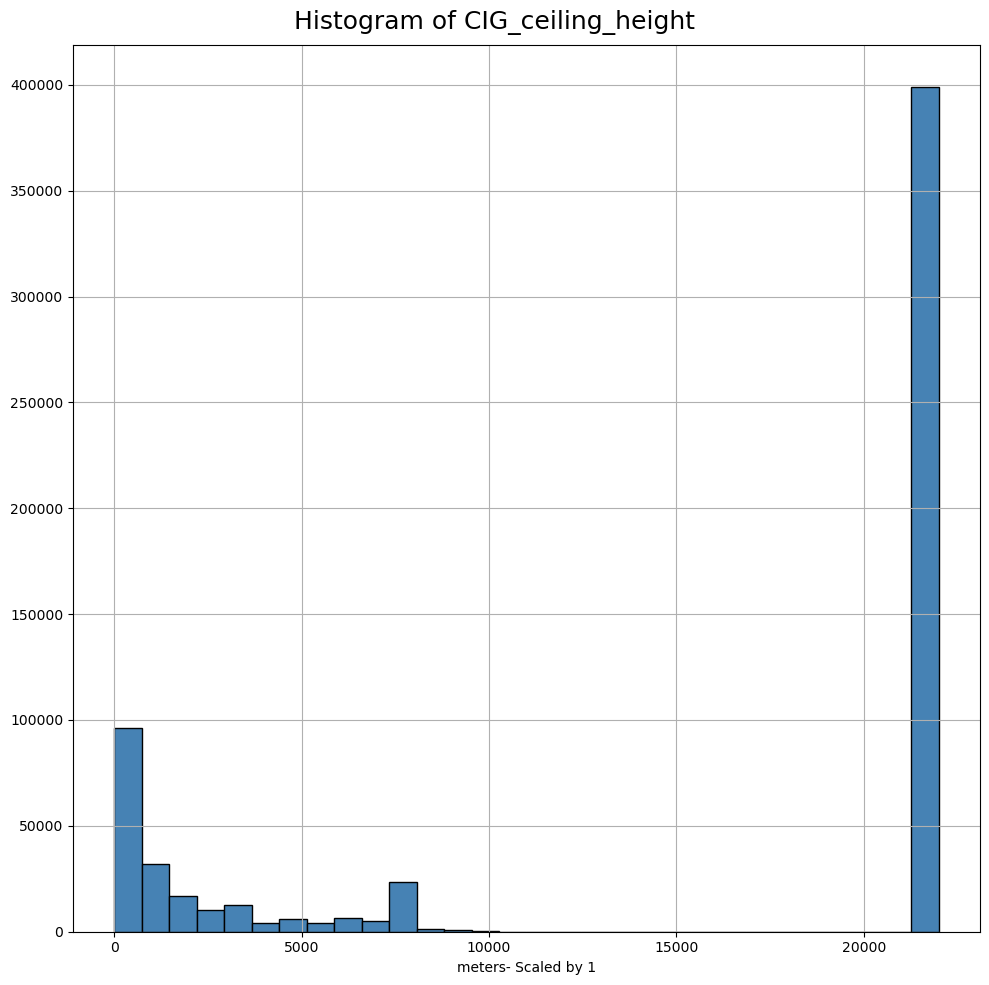

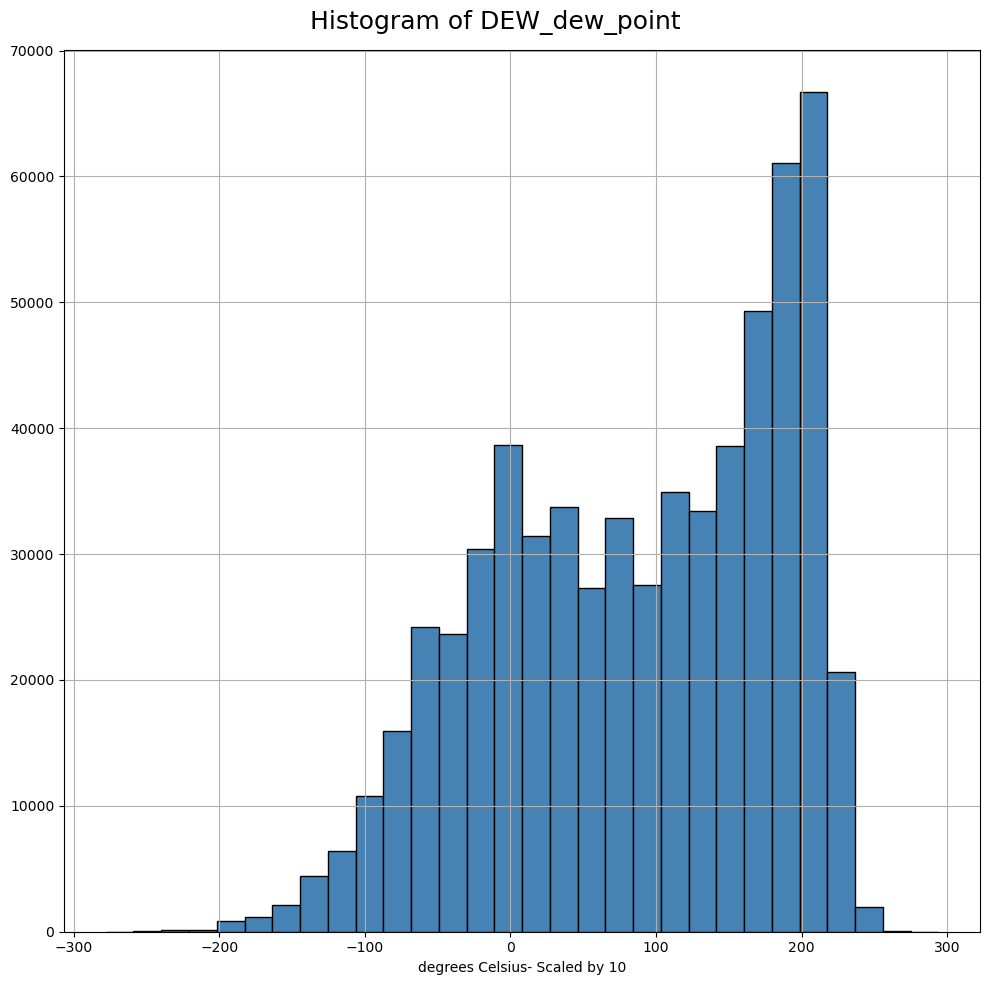

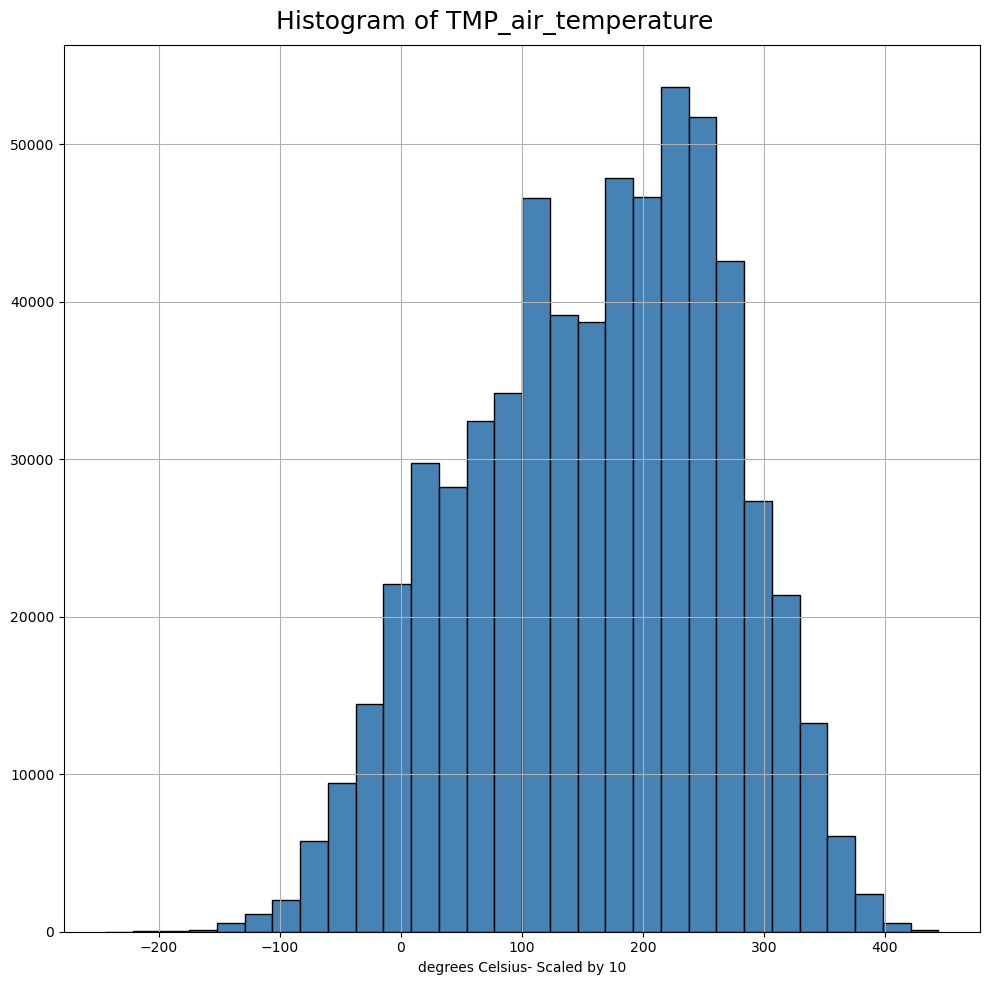

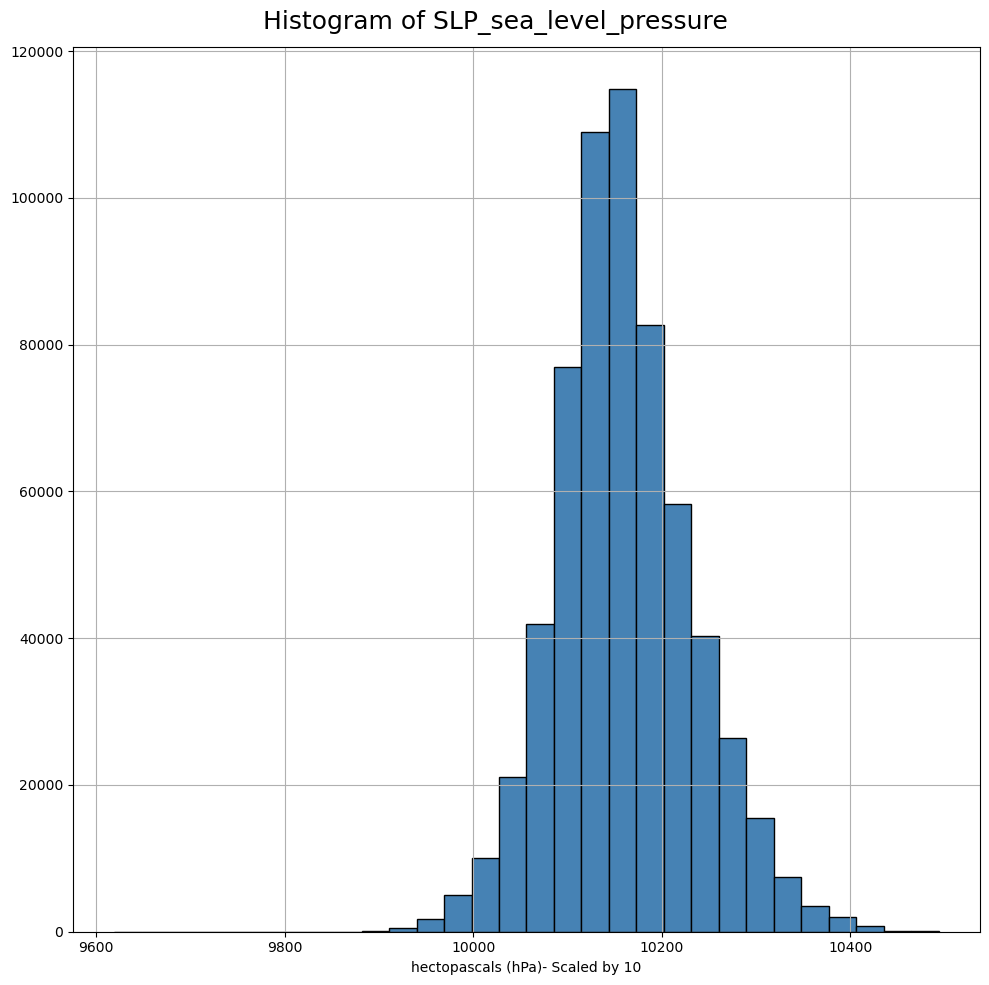

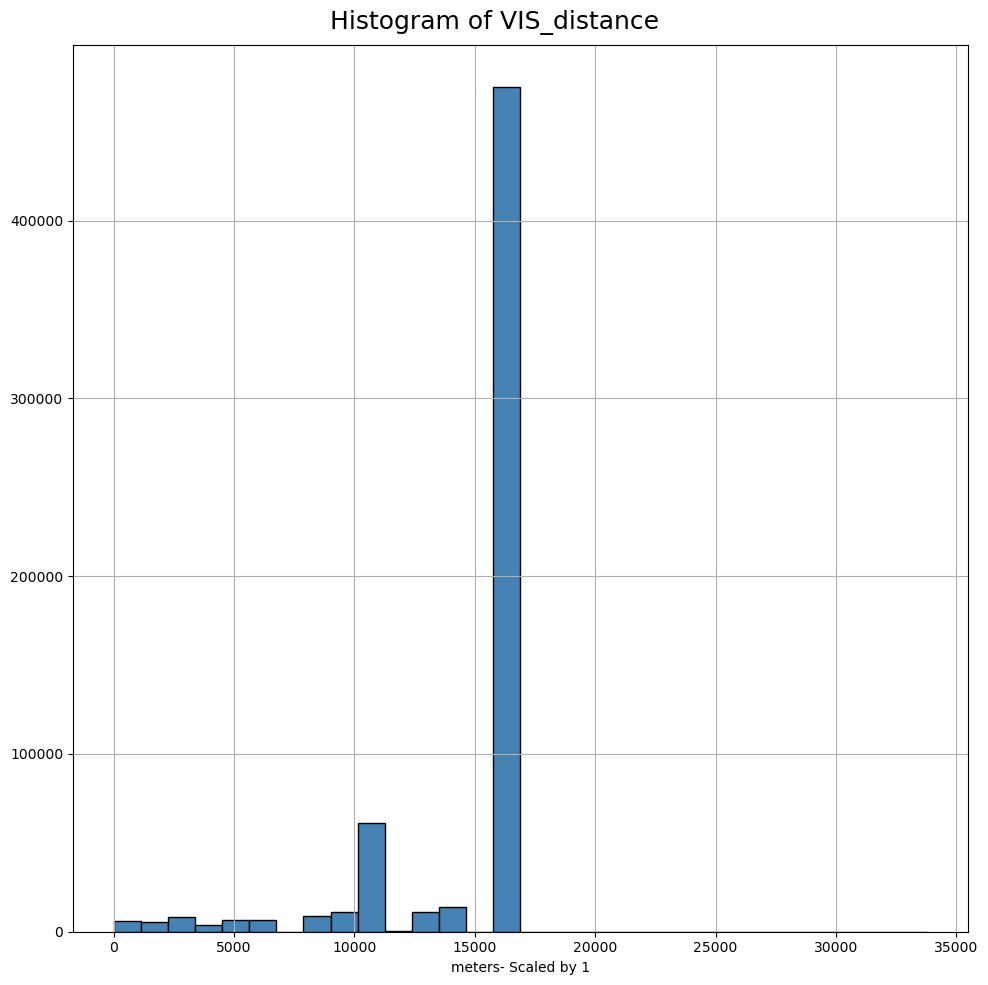

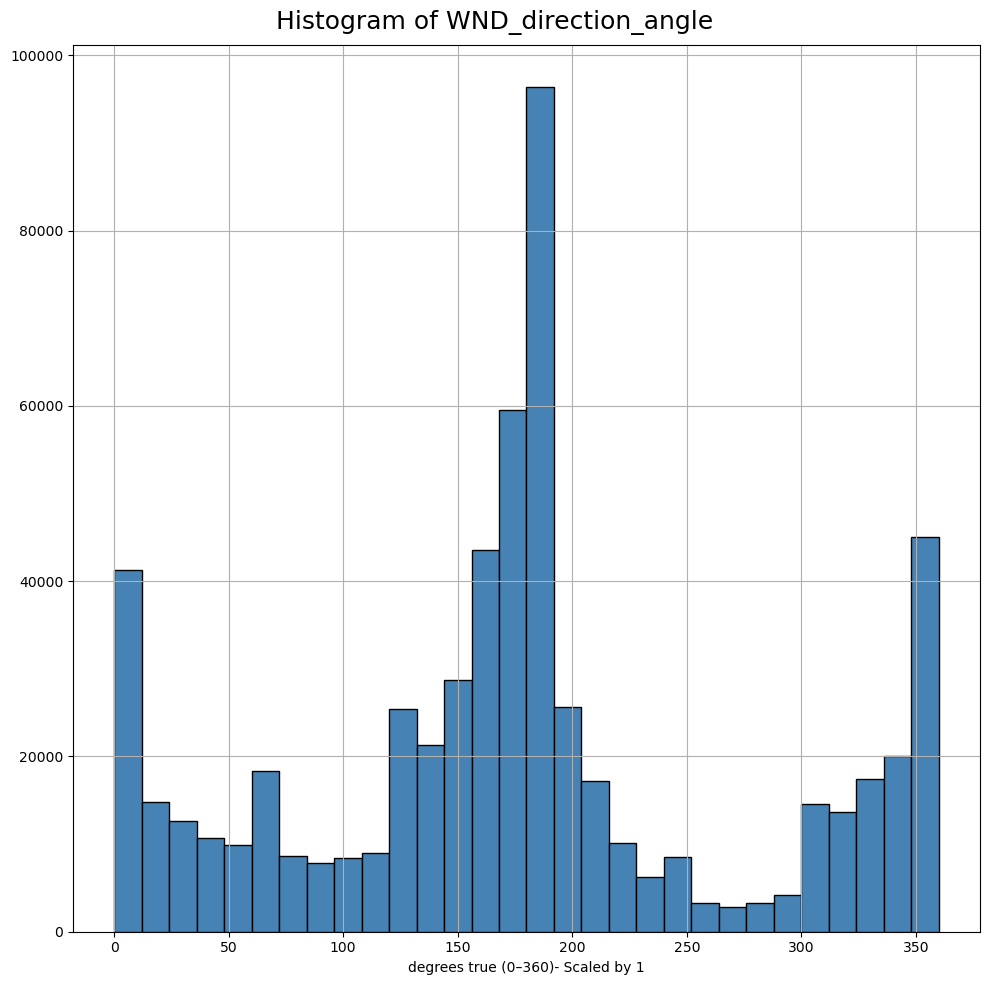

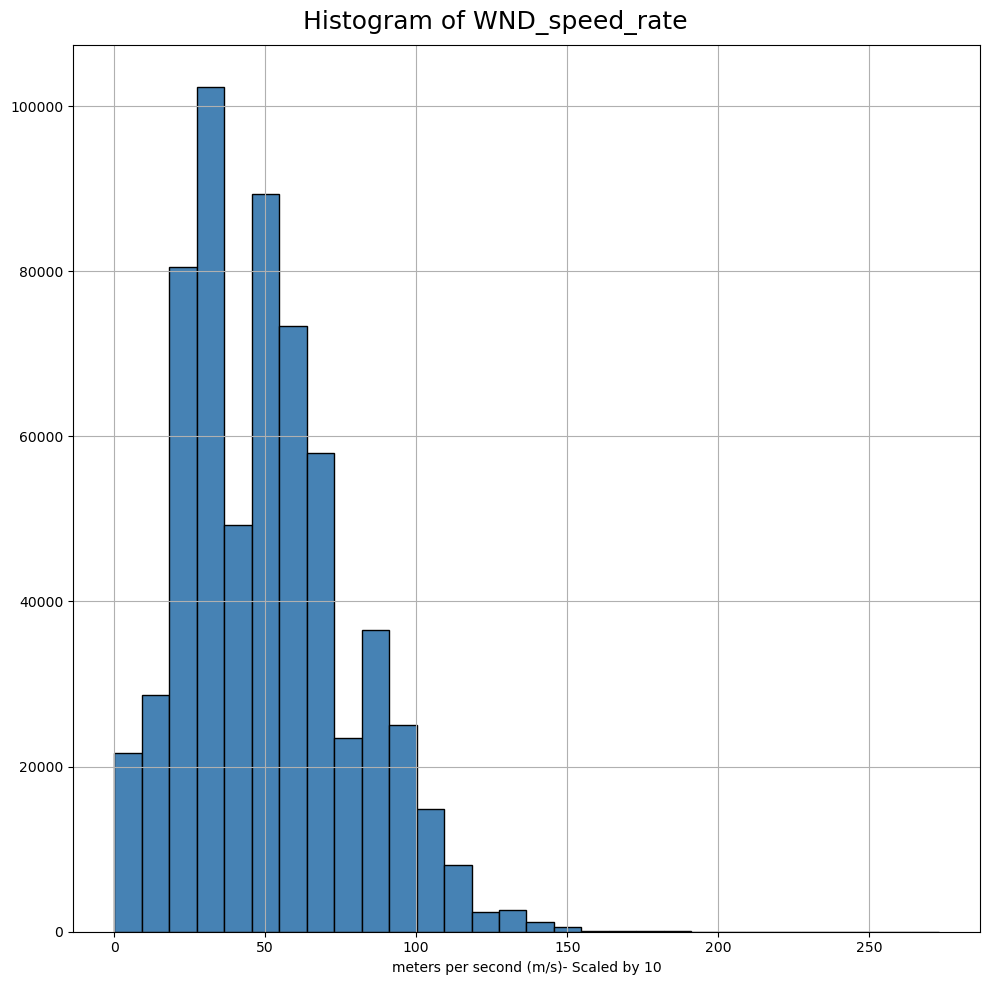

In [26]:
isd_float_meteor_columns = metadata.isd_float_meteor_columns

for col,vals in isd_float_meteor_columns.items():
    data[col].hist(
        bins=30,            # number of bins per histogram
        figsize=(10,10),   # overall figure size
        color='steelblue',  # bar color
        edgecolor='black'   # border color
    )
    
    plt.xlabel(f"{vals['units']}- Scaled by {vals['scale']}")
    plt.suptitle(f"Histogram of {col}", fontsize=18)
    plt.tight_layout()
    # valid names for figure paths
    title = f"{col} Histogram"
    filename = f"{col}_histogram.png"
    save_to_path = pathlib.Path(f"results/eda_figures/histograms/{filename}")
    plt.savefig(project_root/save_to_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    plt.close()


    



#### Histogram Observations


#### [CIG — Sky Condition Observation (Ceiling Height Dimension)](<../results/eda_figures/histograms/CIG_ceiling_height_histogram.png>)
The ceiling height distribution is highly bimodal and strongly asymmetric, with a dominant spike at 22,000 m, corresponding to “unlimited ceiling” or clear sky conditions in ISD standards. The secondary cluster below 2,000 m represents overcast or cloudy conditions. 
It is important to note that in handling NaN values in this feature, we did send a few to 22000 (clear skies). 

#### [DEW — Dew Point Temperature](<../results/eda_figures/histograms/DEW_Dew_Point_Temperature_histogram.png>)
The dew point histogram skewed to the right, showing most values between 0°C and 20°C (scaled ×10), with a long tail extending into subzero temperatures. The strong clustering at higher dew points indicates high moisture content for a significant number of samples— a key tornado precursor. This makes sense especially for a tornado prone state such as Oklahoma. Such heavy-tailed structure is typical in meteorological data and may benefit from log transformation before regression or classification.


#### [SLP — Sea Level Pressure](<../results/eda_figures/histograms/SLP_sea_level_pressure_histogram.png>)
Sea level pressure observations follow a slightly left-skewed, near-normal distribution centered around 1015 hPa (scaled by 10). Minor left skew suggests slightly more frequent low-pressure readings, consistent with the stormy or unstable periods captured by the dataset. 

#### [TMP — Air Temperature](<../results/eda_figures/histograms/TMP_air_temperature_histogram.png>)
The temperature distribution follows a right-skewed distribution, peaking between 19°C and 25°C (scaled by 10). Lower tails extend into subfreezing temperatures, representing nighttime or winter readings. Such heavy-tailed structure is typical in meteorological data and may benefit from log transformation before regression or classification.

####  [VIS — Visibility (Distance Dimension)](<../results/eda_figures/histograms/VIS_distance_histogram.png>)
Visibility has a pronounced spike at around 16,000 meters, which is the ISD’s “maximum measurable visibility.” The remainder of the data declines rapidly toward lower distances, suggesting that full-visibility conditions dominate, which is too be expected. 

#### [WND — Wind Direction Angle](<../results/eda_figures/histograms/WND_direction_angle_histogram.png>)
Wind direction forms a multimodal distribution, with peaks near 5° (north), 150–200° (south-southwest), and 350-360° (north-northwest). 

#### [WND — Wind Speed Rate](<../results/eda_figures/histograms/WND_speed_rate_histogram.png>)
Wind speed rates exhibit a left skewed distribution, with most values between 0–80 m/s (scaled ×10) 


### 7.2 KDE Plots 

To complement the univariate histograms, the following kernel density estimates (KDEs) visualize the probability distributions of meteorological variables conditioned on tornado occurrence. These plots allow for a direct comparison of atmospheric regimes, showing where tornado-related observations deviate from background weather patterns. By contrasting densities between the two groups, we identify which environmental factors most strongly characterize tornadic environments.

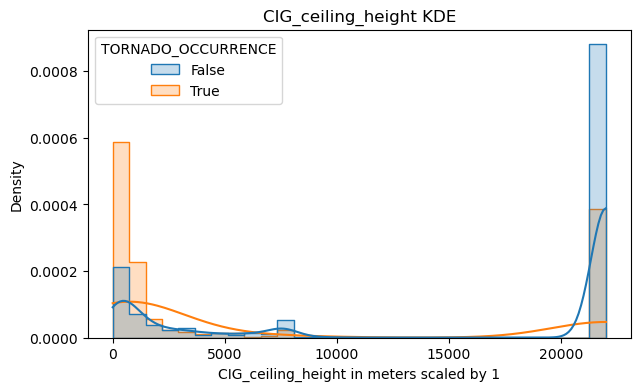

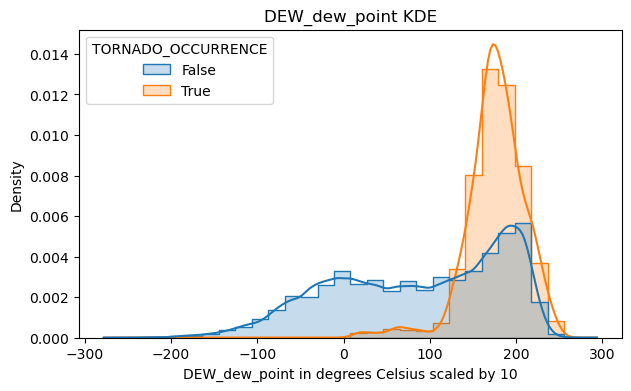

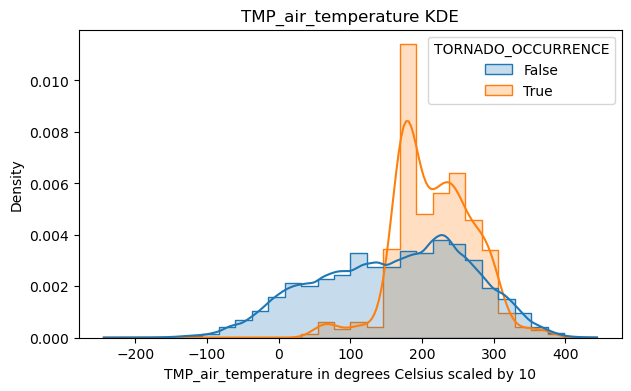

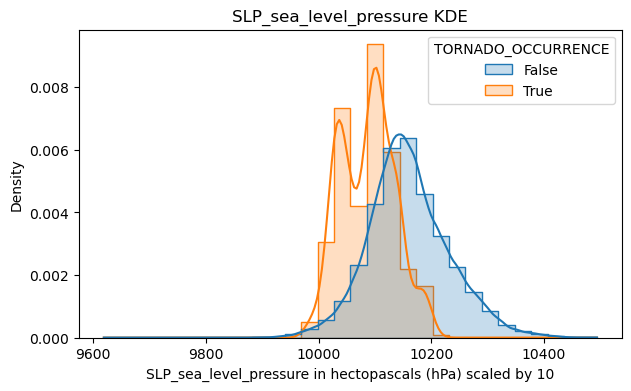

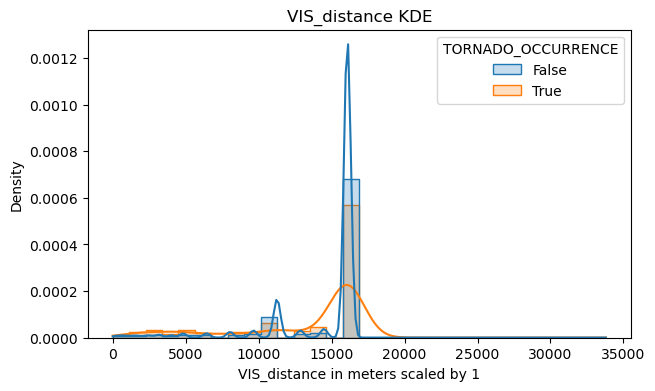

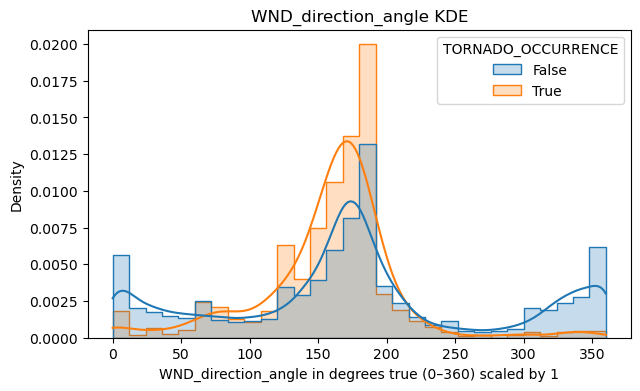

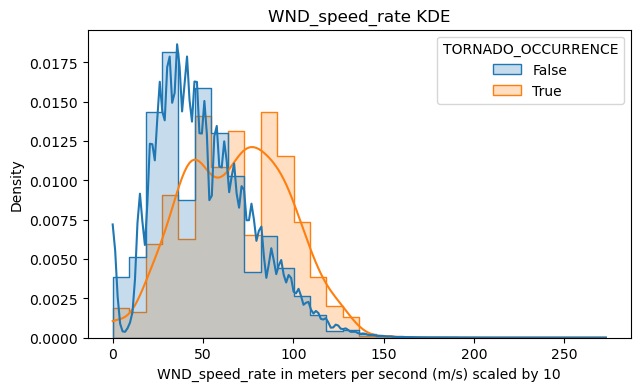

In [29]:


# Select a few weather variables to visualize


for col,vals in isd_float_meteor_columns.items():
    plt.figure(figsize=(7,4))
    sns.histplot(
        data=data,
        x=col,
        hue='TORNADO_OCCURRENCE',
        bins=30,
        kde=True,
        element='step',
        stat='density',
        common_norm=False
    )
    title = f"{col} KDE"
    filename = f"{col}_kde.png"
    plt.title(title)
    plt.xlabel(f"{col} in {vals['units']} scaled by {vals['scale']}")
    plt.ylabel("Density")
    save_to_path = pathlib.Path(f"results/eda_figures/sns_density_histograms/{filename}")
    plt.savefig(project_root/save_to_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    plt.close()




#### [CIG — Sky Condition Observation (Ceiling Height Dimension)](<../results/eda_figures/sns_density_histograms/CIG_ceiling_height_kde.png>)
The ceiling height distribution is strongly bimodal, with the non-tornado class (blue) peaking sharply at 22,000 m (clear skies). Tornado-associated observations (orange) occur  at much lower ceiling heights, indicating more frequent cloud cover or overcast conditions during tornadic environments. There are two tornado peaks near low ceiling height and another at 22000m (max) ceiling height

**However**, an odd anomaly is that there are a significant number of tornadoes occurring when the ceiling height is 22000. Likely this is because of our NaN convention above when we set NaN values in this feature to 22000. It might be good to drop this feature before model training for this reason.

#### [DEW — Dew Point Temperature](<../results/eda_figures/sns_density_histograms/DEW_dew_point_kde.png>)
Tornado events cluster around higher dew point values (150–220 × 0.1 °C), in contrast with a broader, cooler distribution for non-tornado cases. 


#### [SLP — Sea Level Pressure](<../results/eda_figures/sns_density_histograms/SLP_sea_level_pressure_kde.png>)
Again a similar pattern to the distributions for the altimeter setting rates and station pressure rates. 

#### [TMP — Air Temperature](<../results/eda_figures/sns_density_histograms/TMP_air_temperature_kde.png>)
Air temperature distributions show that tornadoes favor warmer ambient conditions, with the orange density peaking near 170–290 (× 0.1 °C).

#### [VIS — Visibility Observation (Distance Dimension)](<../results/eda_figures/sns_density_histograms/VIS_distance_kde.png>)
Visibility patterns reveal a dominance of maximum-measured values (16,000 m) for both classes. However, below the rightmost extreme the tornado distribution is more broadly distributed than its non-tornado counterpart. 

**In addition to the CIG Ceiling Height Dimensions features, this is another feature that we might consider dropping before training models.**

#### [WND — Wind Direction Angle](<../results/eda_figures/sns_density_histograms/WND_direction_angle_kde.png>)
Both distributions are multimodal, but tornado-associated winds are  concentrated more around southerly to southwesterly directions (150–200°). Likely not a great indicator of tornadic lead-up since it is somewhat similar to the non-tornadic winds.

#### [WND — Wind Speed Rate](<../results/eda_figures/sns_density_histograms/WND_speed_rate_kde.png>)
The tornado distribution is skewed toward higher wind speeds than it's counterpart. 





### 7.3 Boxplots with WND Type Code

We now look at boxplots with our numeric meterological features together with our categorical meterological feature `WND- Wind Observation- Type Code`.

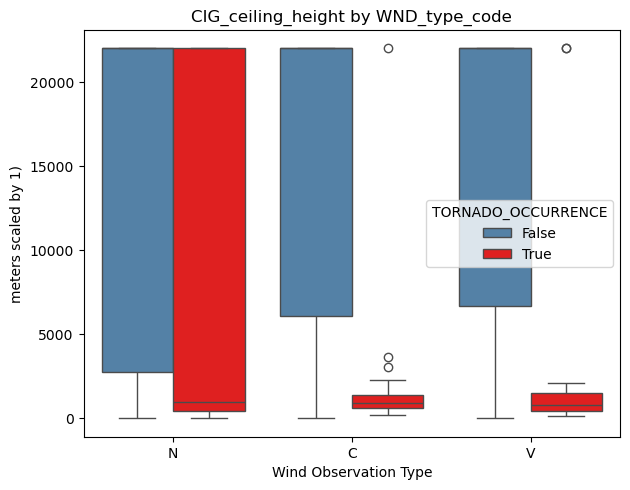

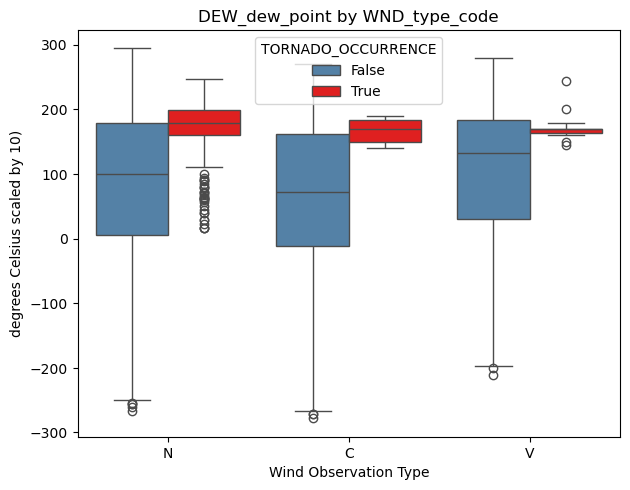

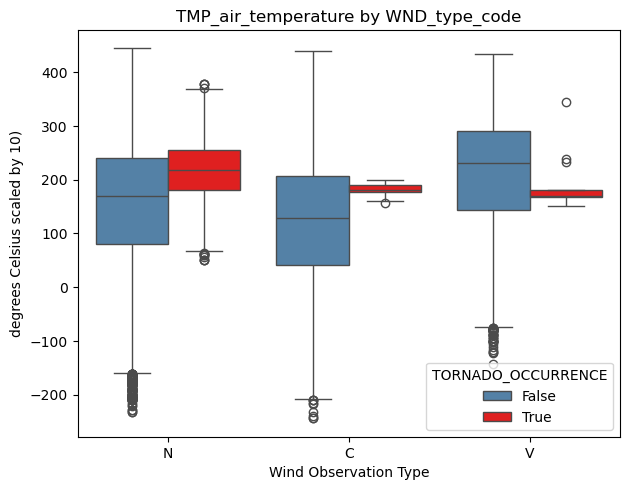

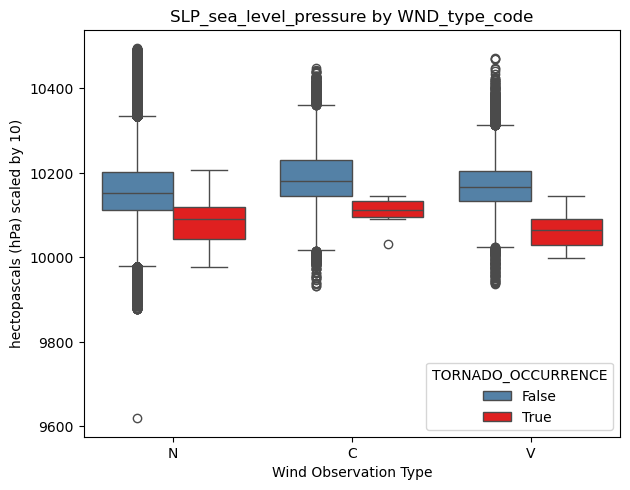

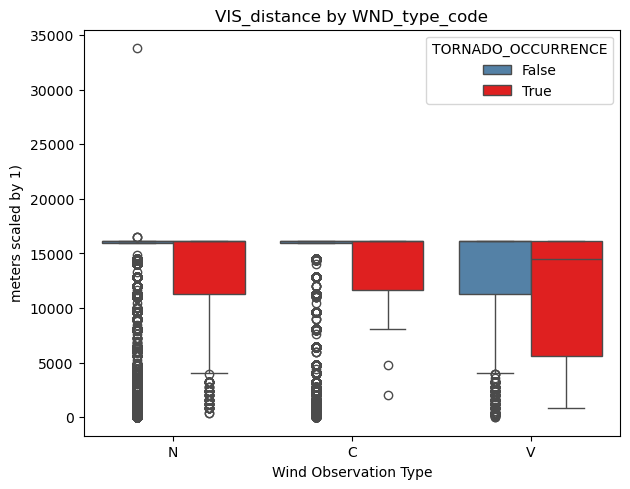

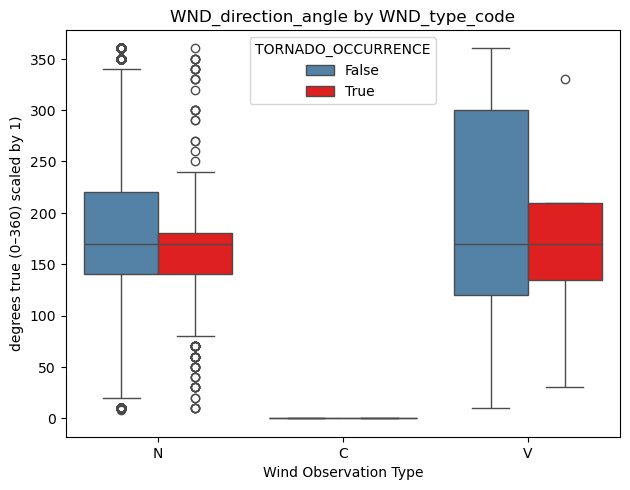

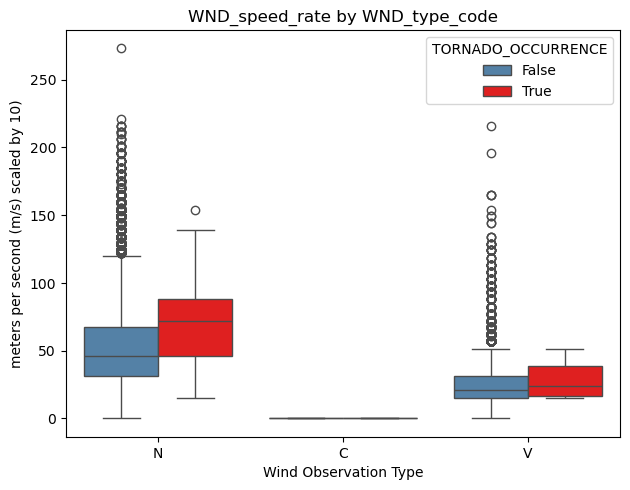

In [30]:

for col_y, vals in isd_float_meteor_columns.items():
    x= 'WND_type_code'
    sns.boxplot(
        data=data,
        x=x,
        y= col_y,
        hue='TORNADO_OCCURRENCE',
        palette={True: 'red', False: 'steelblue'}
    )
    title = f"{col_y} by {x}"
    filename= f"{col_y}_by_{x}"
    
    plt.xlabel('Wind Observation Type')
    plt.ylabel(f'{vals['units']} scaled by {vals['scale']})')
    plt.tight_layout()
    plt.title(title)
    save_to_path = pathlib.Path(f'results/eda_figures/boxplots/{filename}.png')
    plt.savefig(project_root/save_to_path, dpi=300)
    plt.show()
    
    plt.close()




#### Overall Observation Summary

* `VIS_distance` and `WND_Type_Code` seem to capture tornado occurrence very well when the type code is `N` or `C`. This is interesting.

* * `CIG_ceiling Height` and `WND_Type_Code` seem to capture tornado occurrence very well when the type code is `C` or `V`. 

* The boxplots for tornadic versus non-tornadic events appear to be concentrated in distinct sea level pressures when compared against wind type code.

* Tornadic events seem to be very concentrated when DEW and TMP are compared against wind type and the wind type is `C` or `V`.



### 7.5 Box Plots with CAVOK Code

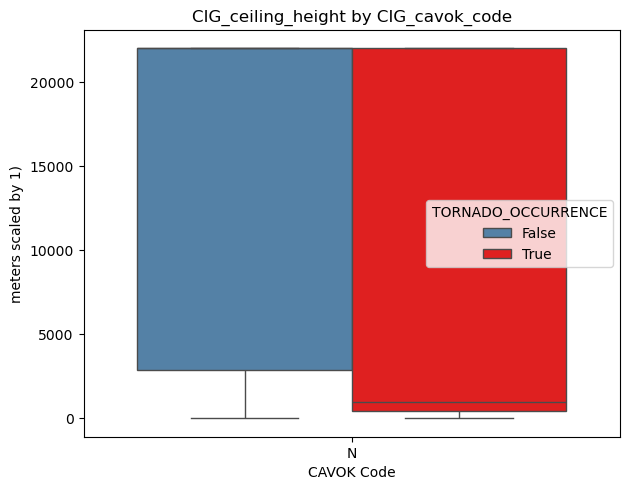

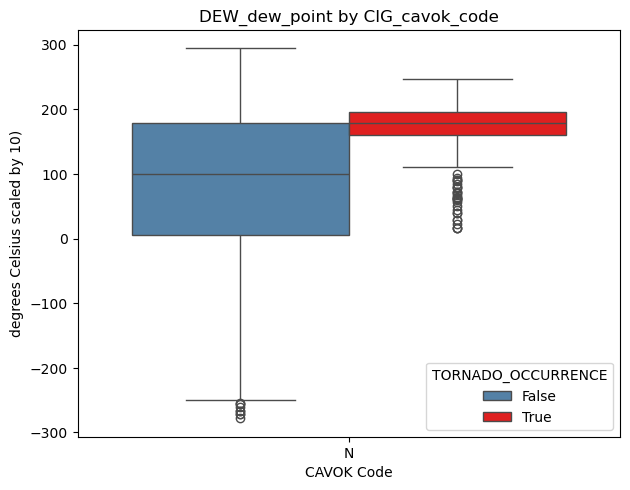

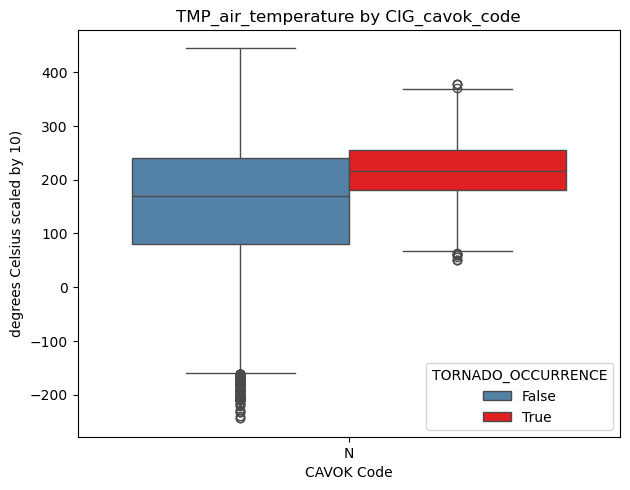

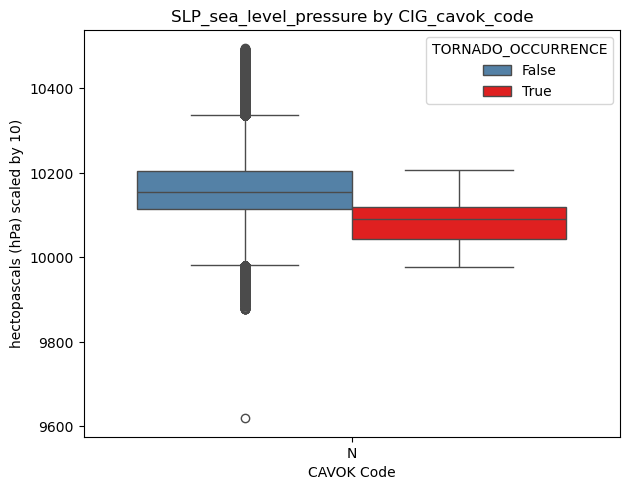

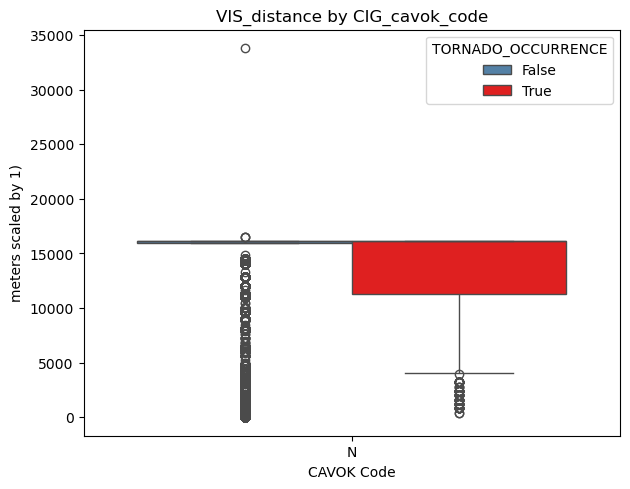

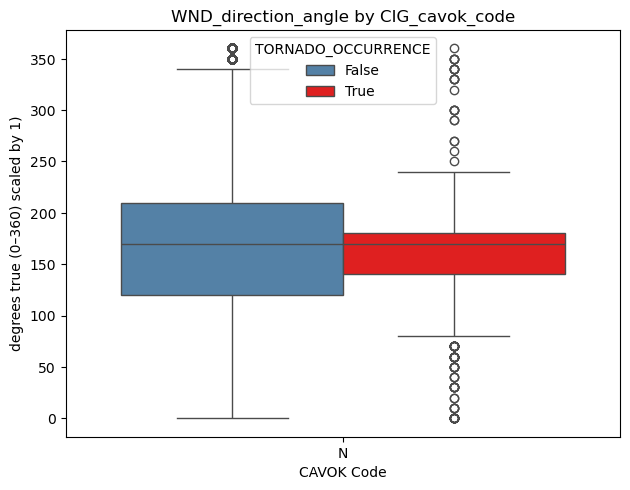

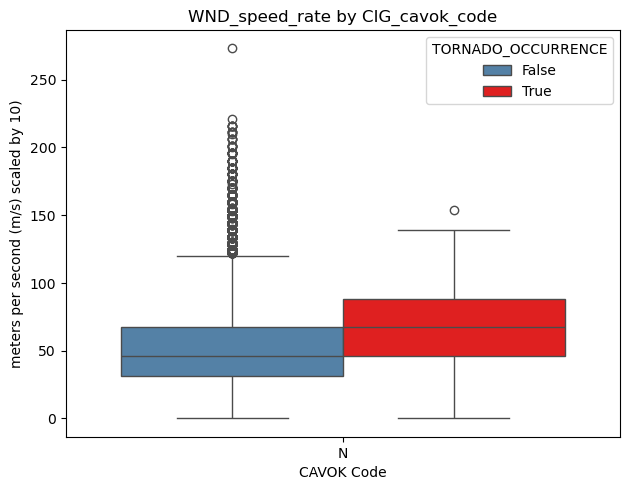

In [31]:
for col_y, vals in isd_float_meteor_columns.items():
    x= 'CIG_cavok_code'
    sns.boxplot(
        data=data,
        x=x,
        y= col_y,
        hue='TORNADO_OCCURRENCE',
        palette={True: 'red', False: 'steelblue'}
    )
    title = f"{col_y} by {x}"
    filename= f"{col_y}_by_{x}"
    
    plt.xlabel('CAVOK Code')
    plt.ylabel(f'{vals['units']} scaled by {vals['scale']})')
    plt.tight_layout()
    plt.title(title)
    save_to_path = pathlib.Path(f'results/eda_figures/boxplots/{filename}.png')
    plt.savefig(project_root/save_to_path, dpi=300)
    plt.show()
    
    plt.close()

### General Observations:

* `Vis_distance` and `SLP` again seems to be a decent indicator of tornadic events when CAVOK code is taken into account. 

### 7.6 Boxplots with VIS_Variability Code

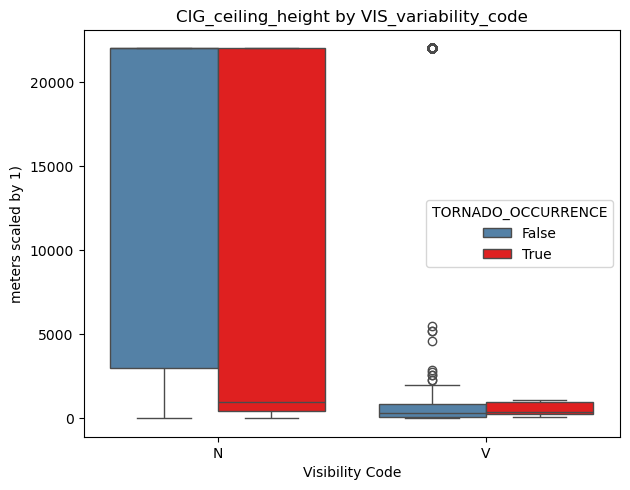

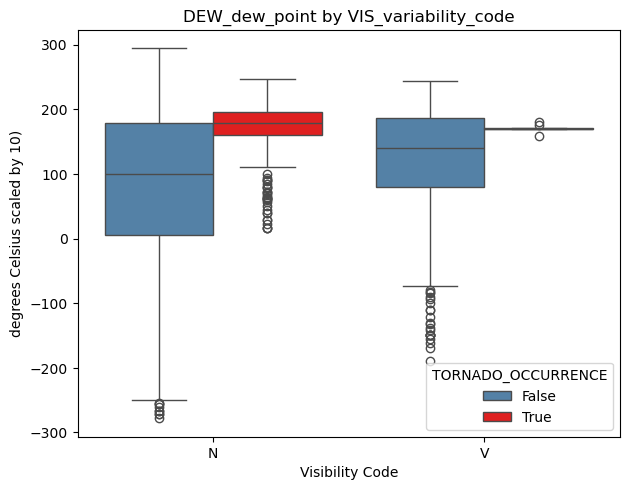

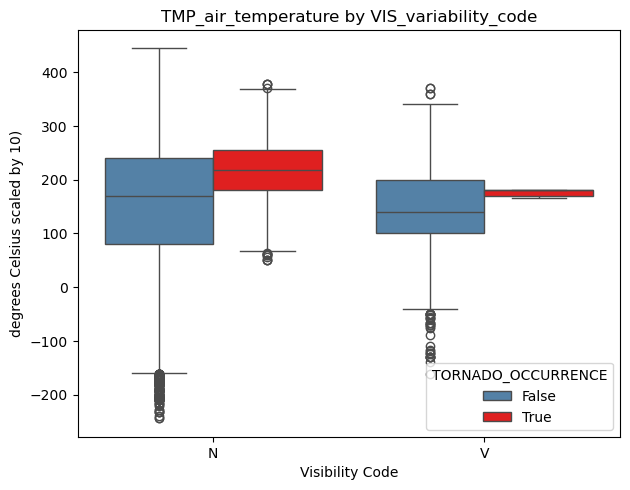

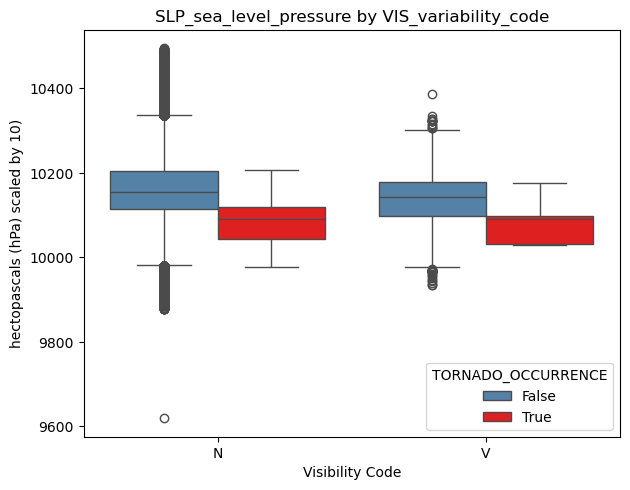

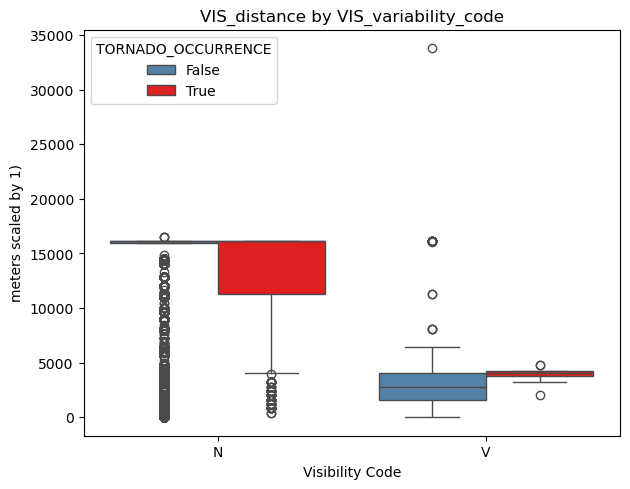

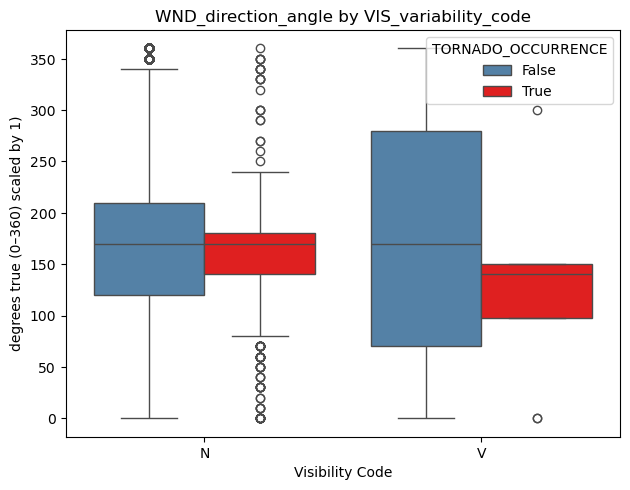

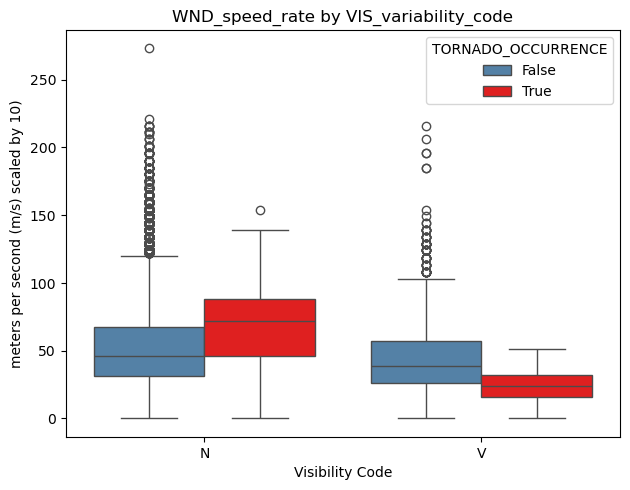

In [32]:
for col_y, vals in isd_float_meteor_columns.items():
    x= 'VIS_variability_code'
    sns.boxplot(
        data=data,
        x=x,
        y= col_y,
        hue='TORNADO_OCCURRENCE',
        palette={True: 'red', False: 'steelblue'}
    )
    title = f"{col_y} by {x}"
    filename= f"{col_y}_by_{x}"
    
    plt.xlabel('Visibility Code')
    plt.ylabel(f'{vals['units']} scaled by {vals['scale']})')
    plt.tight_layout()
    plt.title(title)
    save_to_path = pathlib.Path(f'results/eda_figures/boxplots/{filename}.png')
    plt.savefig(project_root/save_to_path, dpi=300)
    plt.show()
    
    plt.close()

* DEW, SLP, and Visibility Distance when compared again Visibility Code appear to distinguish tornadic from non-tornadic events.

### 7.7 Boxplots with Wind Angle Flag

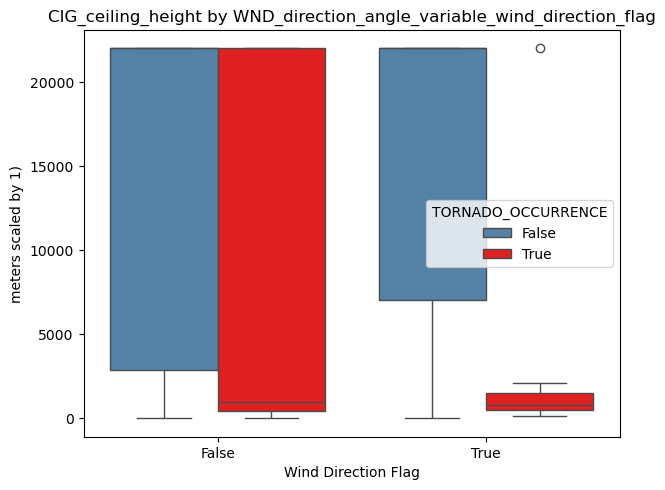

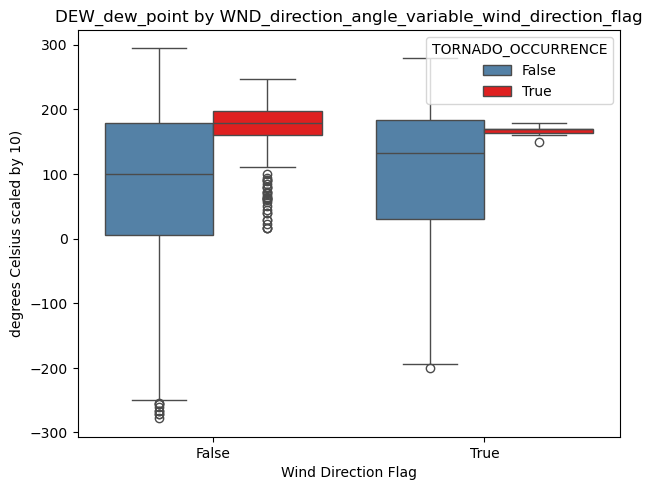

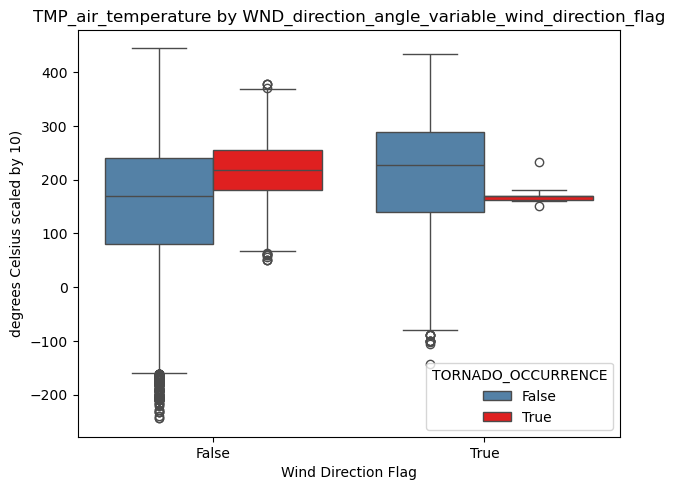

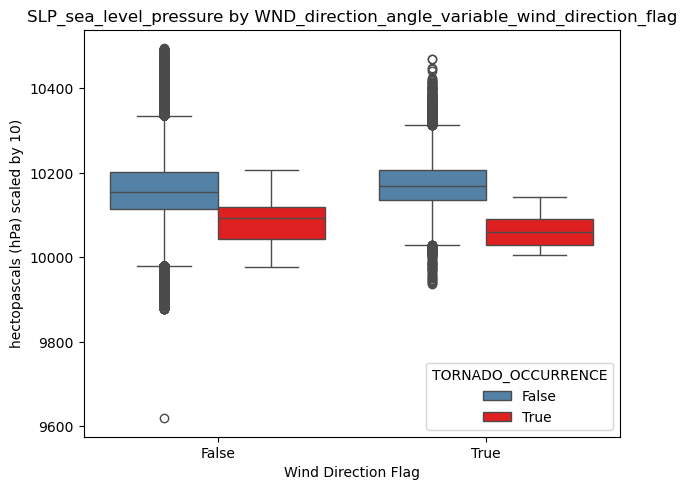

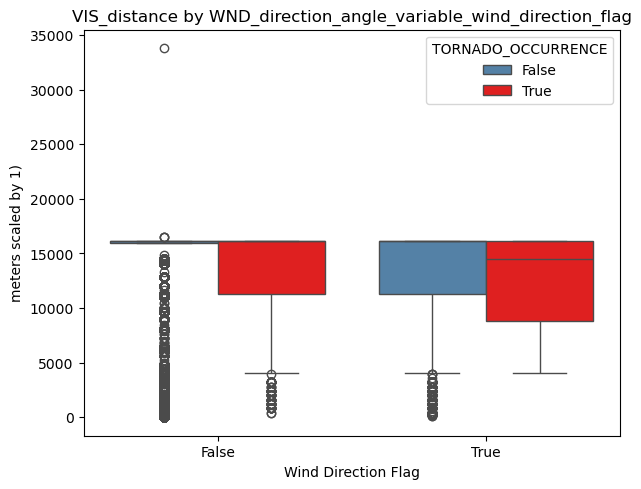

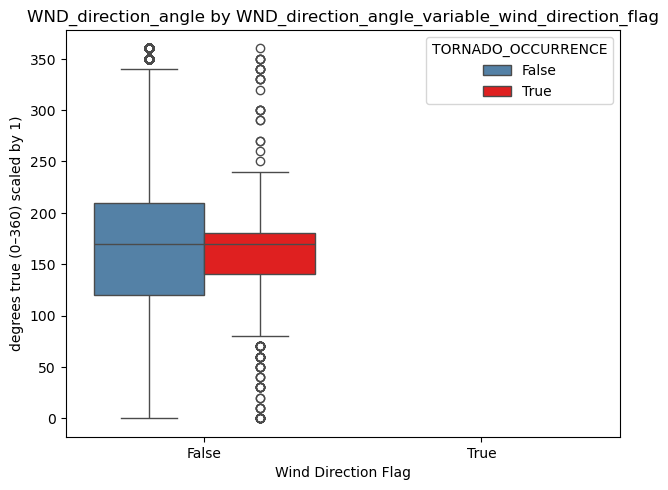

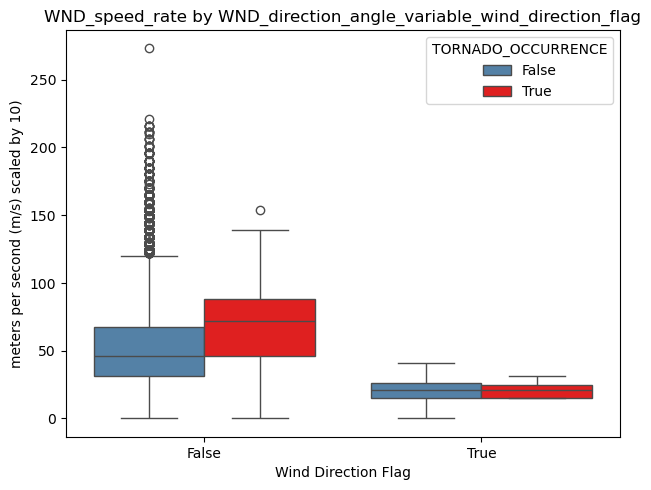

In [33]:
for col_y, vals in isd_float_meteor_columns.items():
    x= 'WND_direction_angle_variable_wind_direction_flag'
    sns.boxplot(
        data=data,
        x=x,
        y= col_y,
        hue='TORNADO_OCCURRENCE',
        palette={True: 'red', False: 'steelblue'}
    )
    title = f"{col_y} by {x}"
    filename= f"{col_y}_by_{x}"
    
    plt.xlabel('Wind Direction Flag')
    plt.ylabel(f'{vals['units']} scaled by {vals['scale']})')
    plt.tight_layout()
    plt.title(title)
    save_to_path = pathlib.Path(f'results/eda_figures/boxplots/{filename}.png')
    plt.savefig(project_root/save_to_path, dpi=300)
    plt.show()
    
    plt.close()

### 7.8 Correlation Matrix

The code belows creates and displays a Pearson correlation matrix heatmap. This is key in finding variables that are highly correlated.

* The Pearson Correlation Matrix can be found here [results/eda_summaries/correlation_matrix.csv](<../results/eda_summaries/correlation_matrix.csv>).

* The displayed heatmap can be found here [results/eda_figures/correlation/correlation_heatmap.png](<r../esults/eda_figures/correlation/correlation_heatmap.png>).

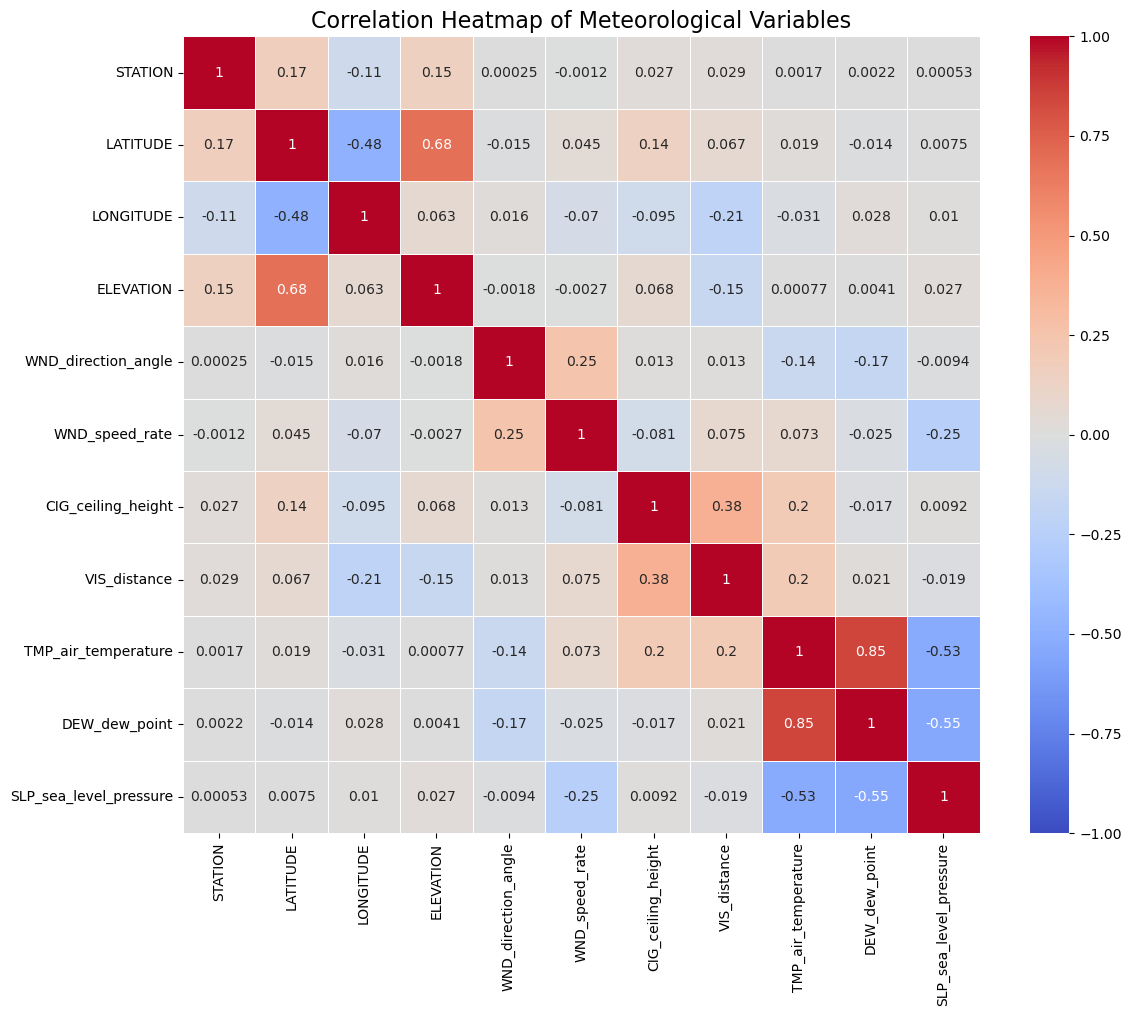

In [34]:

corr_matrix = data.select_dtypes(include=np.number).corr(method='pearson')

# Save correlation matrix to CSV
save_to_path = pathlib.Path('results/eda_summaries/correlation_matrix.csv')
corr_matrix.to_csv(project_root/save_to_path)

# Set up figure
plt.figure(figsize=(12,10))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    center=0,
    annot=True,       # change to True if you want numbers shown
    square=True,
    linewidths=0.5,
)
plt.title('Correlation Heatmap of Meteorological Variables', fontsize=16)
plt.tight_layout()

# Save figure
save_to_path = pathlib.Path('results/eda_figures/correlation/correlation_heatmap.png')
plt.savefig(project_root/save_to_path, dpi=300, bbox_inches='tight')
plt.show()

plt.close()

#### Correlation Matrix Summary

A few of the correlations:

| Feature 1                         | Feature 2                            | Corr. (r)            | Interpretation                                                                                                                                                  |
| --------------------------------- | ------------------------------------ | -------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **TMP — Air Temperature**         | **DEW — Dew Point Temperature**      | **+0.85**          | Strong thermodynamic coupling: warmer air tends to hold more moisture, leading to higher dew points. These two features are nearly redundant for linear models. |
| **TMP - Air Temperature** | **SLP - Sea Level Pressure** |**-0.53** | Mild negative correlation between temperature and sea level pressure. |
| **DEW -Dew Point Temperature** | **SLP - Sea Level Pressure** |**-0.55** | Mild negative correlation between temperature and sea level pressure. |
| **Station Latitude**              | **Station Longitude**                | **-.48**          | Solely used for creating the TORNADO_OCCURRENCE column, so these will be dropped before model training.                           




**Interpretation and Modeling Implications**

*  (TMP, DEW) are highly collinear. For logistic regression or linear models, drop one from each correlated pair.

* For tree-based models, these can be safely retained — the algorithm will handle redundancy, though feature importance may be split. 

* Geospatial features (LAT, LON) coordinate points are solely used for creating the TORNADO_OCCURRENCE column, so these will be dropped before model training.


### Note On Scatterplots

Pairwise scatter plots were considered but ultimately omitted due to the large dataset size and the strong linear structure already summarized in the correlation matrix. The combination of univariate histograms, conditional KDEs, and categorical boxplots already provides sufficient coverage of distributional shape, separation, and potential redundancy among features. Scatter plots would add visual clutter without additional interpretive value at this scale.

### 7.9 Temporal Patterns

We examine the temporal distribution of tornado occurrences, we aggregate tornado indicators by month and by hour of the day. 

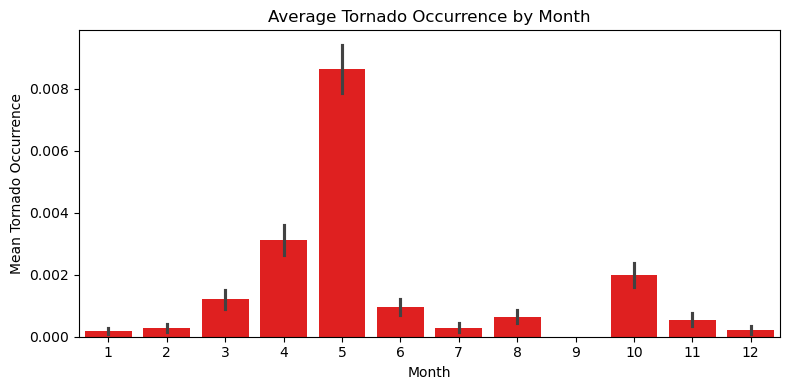

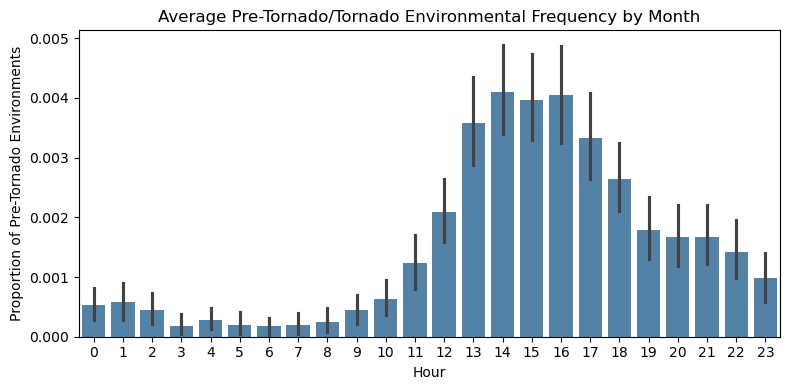

In [35]:
# Extract datetime features
data['DATE'] = pd.to_datetime(data['DATE'], errors='coerce')
data['month'] = data['DATE'].dt.month
data['hour'] = data['DATE'].dt.hour

# Tornado frequency by month
plt.figure(figsize=(8,4))
sns.barplot(
    data=data,
    x='month',
    y='TORNADO_OCCURRENCE',
    estimator=np.mean,
    color='red'
)
plt.title("Average Tornado Occurrence by Month")
plt.xlabel("Month")
plt.ylabel("Mean Tornado Occurrence")
plt.tight_layout()
save_to_path = pathlib.Path("results/eda_figures/temporal/tornado_by_month.png")
plt.savefig(project_root/save_to_path, dpi=300)
plt.show()
plt.close()

# Tornado frequency by hour
plt.figure(figsize=(8,4))
sns.barplot(
    data=data,
    x='hour',
    y='TORNADO_OCCURRENCE',
    estimator=np.mean,
    color='steelblue'
)
plt.title("Average Pre-Tornado/Tornado Environmental Frequency by Month")
plt.ylabel("Proportion of Pre-Tornado Environments")
plt.xlabel("Hour")

plt.tight_layout()
save_to_path = pathlib.Path("results/eda_figures/temporal/tornado_by_hour.png")
plt.savefig(project_root/save_to_path, dpi=300)
plt.show()
plt.close()

These patterns show us precisely what we should expect. Namely:

1. Majority of tornadoes occur in spring and in particular during the month of May. 
2. Most tornadoes occur in the early afternoon 13:00 to early evening 16:00.

### 7.10 Tornado Occurrence (Target) Imbalance

The code below finds the frequency of each value (True and False) in the `TORNADO OCCURRENCE` column. This will guide:

* Train and Test splitting to keep the proportions of `TORNADO OCCURRENCE` values the same.

* Cross-Validation strategy to keep proportions.

* Choice of evaluation metrics. We will likely use F1-score, ROC-AUC, PR-AUC


In [36]:
# Tornado occurrence balance
tornado_counts = data['TORNADO_OCCURRENCE'].value_counts(normalize=True)
save_to_path = pathlib.Path("results/eda_summaries/tornado_counts.csv")
tornado_counts.to_csv(project_root/save_to_path)
display(tornado_counts)

TORNADO_OCCURRENCE
False    0.998474
True     0.001526
Name: proportion, dtype: float64

### 7.11 Outlier Analysis

In [37]:
from scipy.stats import zscore

z_scores = np.abs(data[isd_float_meteor_columns.keys()].apply(zscore))
outlier_freq = (z_scores > 1.5).mean().sort_values(ascending=False)
save_to_path = pathlib.Path("results/eda_summaries/outlier_frequency.csv")
outlier_freq.to_csv(project_root/save_to_path)
outlier_freq

CIG_ceiling_height        0.149211
TMP_air_temperature       0.134265
SLP_sea_level_pressure    0.132826
WND_speed_rate            0.124371
DEW_dew_point             0.079416
VIS_distance              0.074251
WND_direction_angle       0.000000
dtype: float64

We might want to get rid of outlier... however tornadoes are outlier events, so perhaps they outliers are predictive of tornadic events.

### 7.12 Feature Scaling/Normality Checks


In [38]:
from scipy.stats import normaltest

for col in isd_float_meteor_columns.keys():
    stat, p = normaltest(data[col].dropna())
    print(f"{col}: p = {p:.4f}")


CIG_ceiling_height: p = 0.0000
DEW_dew_point: p = 0.0000
TMP_air_temperature: p = 0.0000
SLP_sea_level_pressure: p = 0.0000
VIS_distance: p = 0.0000
WND_direction_angle: p = 0.0000
WND_speed_rate: p = 0.0000


As `p` is the probability that these samples come from a normal distribution, we conclude that each of these variables are highly non-normally distributed. This is to be expected from meteorological data. In fact, this confirms what the KDEs already suggested: these features are highly skewed, heavy-tailed, or multimodal. 

Interestingly, the histograms of some of these variables, at first glance, seemed to indicate normality. Thus, illustrating the importance of checking this with more precision.

For downstream modeling:
* Linear or logistic regression: consider transformations on these features.
* Tree-based or ensemble models: no transformation is necessary, as these algorithms are non-parametric and unaffected by non-normal feature distributions.